
## BANKRUPTCY EDA ML
---



The goal of this machine learning project is to develop a predictive model that can assess the financial health of companies and predict the likelihood of bankruptcy based on various financial attributes. The dataset contains a wide range of financial indicators for different companies, including profitability ratios, liquidity ratios, leverage ratios, and operational efficiency metrics. The prediction of bankruptcy is a phenomenon of increasing interest in firms that stand to lose money because of unpaid debts

--
You need to use machine learning algorithms, and aim to analyze these financial attributes and build a predictive model that can classify companies as either financially healthy or at risk of bankruptcy. By leveraging historical financial data and company performance metrics, this model will help investors, financial analysts, and stakeholders identify early warning signs of financial distress and make informed decisions to mitigate risks.


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay

# SMOTE & Scaling
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# For Dump and Load
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# View all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)



In [ ]:
# Load data
data = pd.read_csv("DataFile.csv")   # Replace with your data file

print("Data imported ✅")

Data imported ✅


In [ ]:
data.head()


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan �,Operating Profit Per Share (Yuan �,Per Share Net profit before tax (Yuan �,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256970e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820930e-04,1.165010e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897850e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.006889,0.391590,0.012335,0.7

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 95 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1    ROA(A) before interest and % after tax                   6819 non-null   float64
 2    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3    Operating Gross Margin                                   6819 non-null   float64
 4    Realized Sales Gross Margin                              6819 non-null   float64
 5    Operating Profit Rate                                    6819 non-null   float64
 6    Pre-tax net Interest Rate                                6819 non-null   float64
 7    After-tax net Interest Rate                              6819 non-null   float64
 8    Non-industry inco

In [ ]:
print(f"Data had {data.shape[0]} rows and {data.shape[1]} columns.")

Data had 6819 rows and 95 columns.


In [ ]:
# lets see how columns distributed
nums_cols = []
cats_cols = []
for col in data.columns:
  if data[col].dtype == "O":
    cats_cols.append(col)
  else:
    nums_cols.append(col)
print(f"Total columns:{data.shape[1]}\nNumerical columns:{len(nums_cols)}\nCatgegorical columns:{len(cats_cols)}")

Total columns:95
Numerical columns:95
Catgegorical columns:0


In [ ]:
# lets check data
samples = data.head(5).T
samples = samples.rename(columns={0:"sample_1",1:"sample_2",2:"sample_3",3:"sample_4",4:"sample_5"})
null_dup_dtype = pd.DataFrame({
    "Dtype":data.dtypes,
    "Nulls":data.isnull().sum(),
    "Duplicates":data.duplicated().sum()
})
final_check = pd.concat([null_dup_dtype,samples],axis=1)
final_check

,Dtype,Nulls,Duplicates,sample_1,sample_2,sample_3,sample_4,sample_5
ROA(C) before interest and depreciation before interest,float64,0,0,3.705943e-01,4.642909e-01,4.260713e-01,3.998440e-01,4.650222e-01
ROA(A) before interest and % after tax,float64,0,0,4.243894e-01,5.382141e-01,4.990188e-01,4.512647e-01,5.384322e-01
ROA(B) before interest and depreciation after tax,float64,0,0,4.057498e-01,5.167300e-01,4.722951e-01,4.577333e-01,5.222978e-01
Operating Gross Margin,float64,0,0,6.014572e-01,6.102351e-01,6.014500e-01,5.835411e-01,5.987835e-01
Realized Sales Gross Margin,float64,0,0,6.014572e-01,6.102351e-01,6.013635e-01,5.835411e-01,5.987835e-01
Operating Profit Rate,float64,0,0,9.989692e-01,9.989460e-01,9.988574e-01,9.986997e-01,9.989731e-01
Pre-tax net Interest Rate,float64,0,0,7.968871e-01,7.973802e-01,7.964034e-01,7.969670e-01,7.973661e-01
After-tax net Interest Rate,float64,0,0,8.088094e-01,8.093007e-01,8.083875e-01,8.089656e-01,8.093037e-01
Non-industry income and expenditure/revenue,float64,0,0,3.026464e-01,3.035564e-01,3.020352e-01,3.033495e-01,3.034750e-01
Continuous interest rate (after tax),float64,0,0,7.809848e-01,7.815060e-01,7.802839e-01,7.812410e-01,7.815500e-01


- Data is clean and No Nulls and No duplicates found.
- Except Target column all other columns are Float.

In [ ]:
# lets understand target column
Target_number = data['Bankrupt'].value_counts()
Target_percent = round(data['Bankrupt'].value_counts(normalize=True)*100,2)
pd.concat([Target_number ,Target_percent],axis = 1)

,count,proportion
Bankrupt,,
0,6599,96.77
1,220,3.23


- As Expected it is imbalanced target column so just 3% of Bankruptcy cases out of 6819 datapoints.

In [ ]:
# lets see the correlation between the columns
pearson_corr = data.corr(method = "pearson")
pearson_corr

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan �,Operating Profit Per Share (Yuan �,Per Share Net profit before tax (Yuan �,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
ROA(C) before interest and depreciation before interest,1.000000,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,0.051328,0.066869,0.106461,0.323482,0.048882,0.250761,0.505580,0.505407,0.505281,0.775006,0.379839,-0.015932,0.687201,0.750564,0.000591,0.036511,0.115083,0.115040,0.025234,0.019635,-0.021930,0.079906,0.296158,0.013196,-0.026336,0.003988,-0.022208,-0.261427,0.261427,0.002967,-0.161671,-0.035729,0.685028,0.753339,-0.109888,0.210622,-0.033947,0.007019,-0.062660,-0.065919,0.022896,-0.014834,0.301996,-0.012543,0.259680,0.181993,0.098820,0.235314,-0.010530,-0.046009,-0.210256,0.388151,-0.004447,0.013330,0.052783,0.103819,-0.142734,0.021508,0.650217,0.023450,-0.296019,0.005716,-0.027280,0.001824,-0.029477,0.011759,-0.009192,0.052783,-0.142734,-0.086535,0.262454,0.159699,0.504311,0.129002,-0.160725,-0.109272,0.887670,-0.071725,0.008135,0.334721,0.274287,-0.143629,-0.016575,0.010573,0.052416,-0.260807
ROA(A) before interest and % after tax,0.940124,1.000000,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,0.049909,0.075727,0.084334,0.288440,0.050362,0.225897,0.531799,0.531790,0.531821,0.764828,0.326239,-0.011829,0.654253,0.752578,0.003277,0.042208,0.125384,0.125872,0.024887,0.026977,-0.063970,0.081982,0.263615,0.014102,-0.018412,0.005440,-0.010323,-0.259972,0.259972,0.020707,-0.161868,-0.0361

In [ ]:
spearman_corr = data.corr(method = "spearman")
spearman_corr

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan �,Operating Profit Per Share (Yuan �,Per Share Net profit before tax (Yuan �,Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
ROA(C) before interest and depreciation before interest,1.000000,0.931685,0.989081,0.506232,0.504194,0.806463,0.842781,0.829903,0.386448,0.858867,-0.041300,0.147770,0.473233,-0.118354,0.458064,0.595933,0.595815,0.595247,0.907933,0.520784,0.362882,0.837577,0.894697,0.411926,0.425922,0.471091,0.469238,0.478016,0.207427,0.647279,0.498022,0.363169,0.266577,0.326836,0.174551,-0.252403,-0.247509,0.247509,0.091547,-0.314196,-0.112523,0.837561,0.893486,-0.084846,0.314388,0.087556,-0.095258,-0.100245,-0.019746,0.187960,0.046835,0.710849,-0.125540,0.264368,0.223218,0.114448,0.284832,0.307599,0.279015,-0.173888,0.487171,-0.088502,-0.029022,0.059588,0.198491,-0.201996,-0.084739,0.808604,0.817938,-0.120201,-0.118067,-0.071605,0.137056,-0.085563,0.222884,-0.022180,0.059588,-0.201996,-0.105767,0.237686,0.233247,0.491062,0.232641,-0.265883,-0.055489,0.924448,-0.006847,0.189254,0.506225,0.898858,-0.240925,0.219844,0.183601,0.247505,-0.223589
ROA(A) before interest and % after tax,0.931685,1.000000,0.941016,0.496501,0.494273,0.800226,0.898640,0.899165,0.488196,0.888005,-0.026662,0.117831,0.399679,-0.102959,0.434234,0.648507,0.648368,0.648187,0.947539,0.458678,0.407187,0.851815,0.955232,0.414649,0.428381,0.521446,0.520306,0.492031,0.217052,0.700586,0.533710,0.298908,0.296655,0.334208,0.188814,-0.246323,-0.242536,0.242536,0.228782,-0.339681,-0.068641,

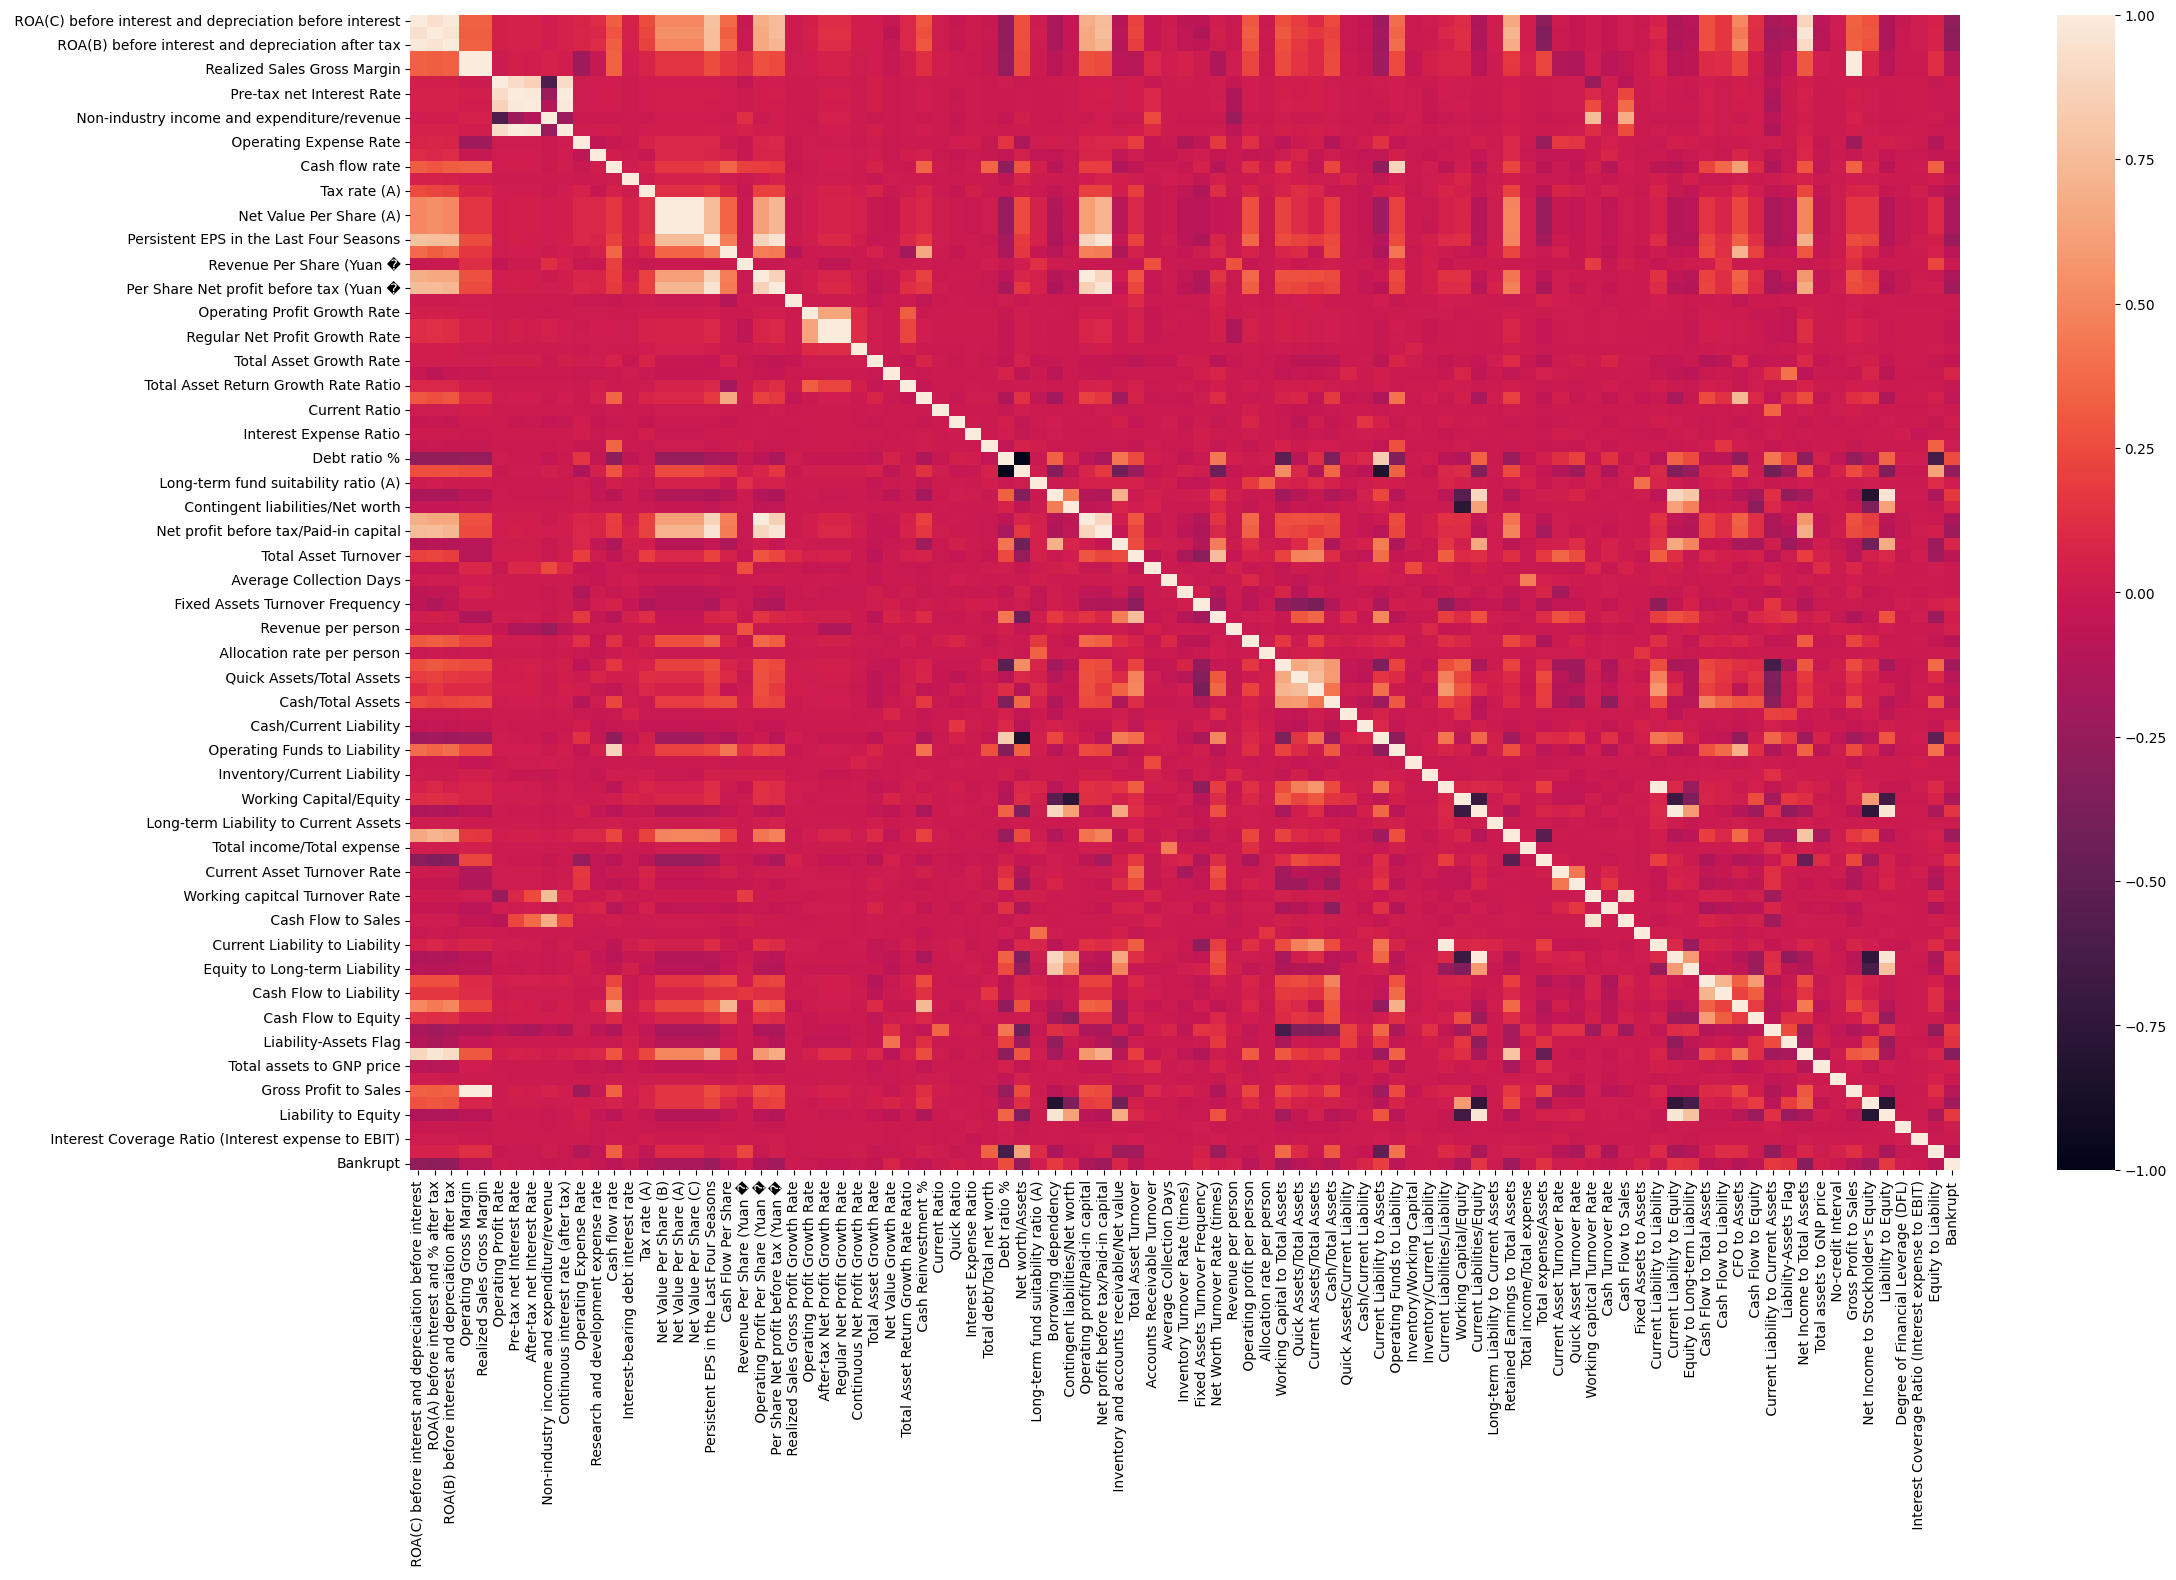

In [ ]:
# correltation with heatmap
plt.figure(figsize=(25,15))
data_corr = data.corr(method="pearson")
sns.heatmap(data.corr())
plt.show()

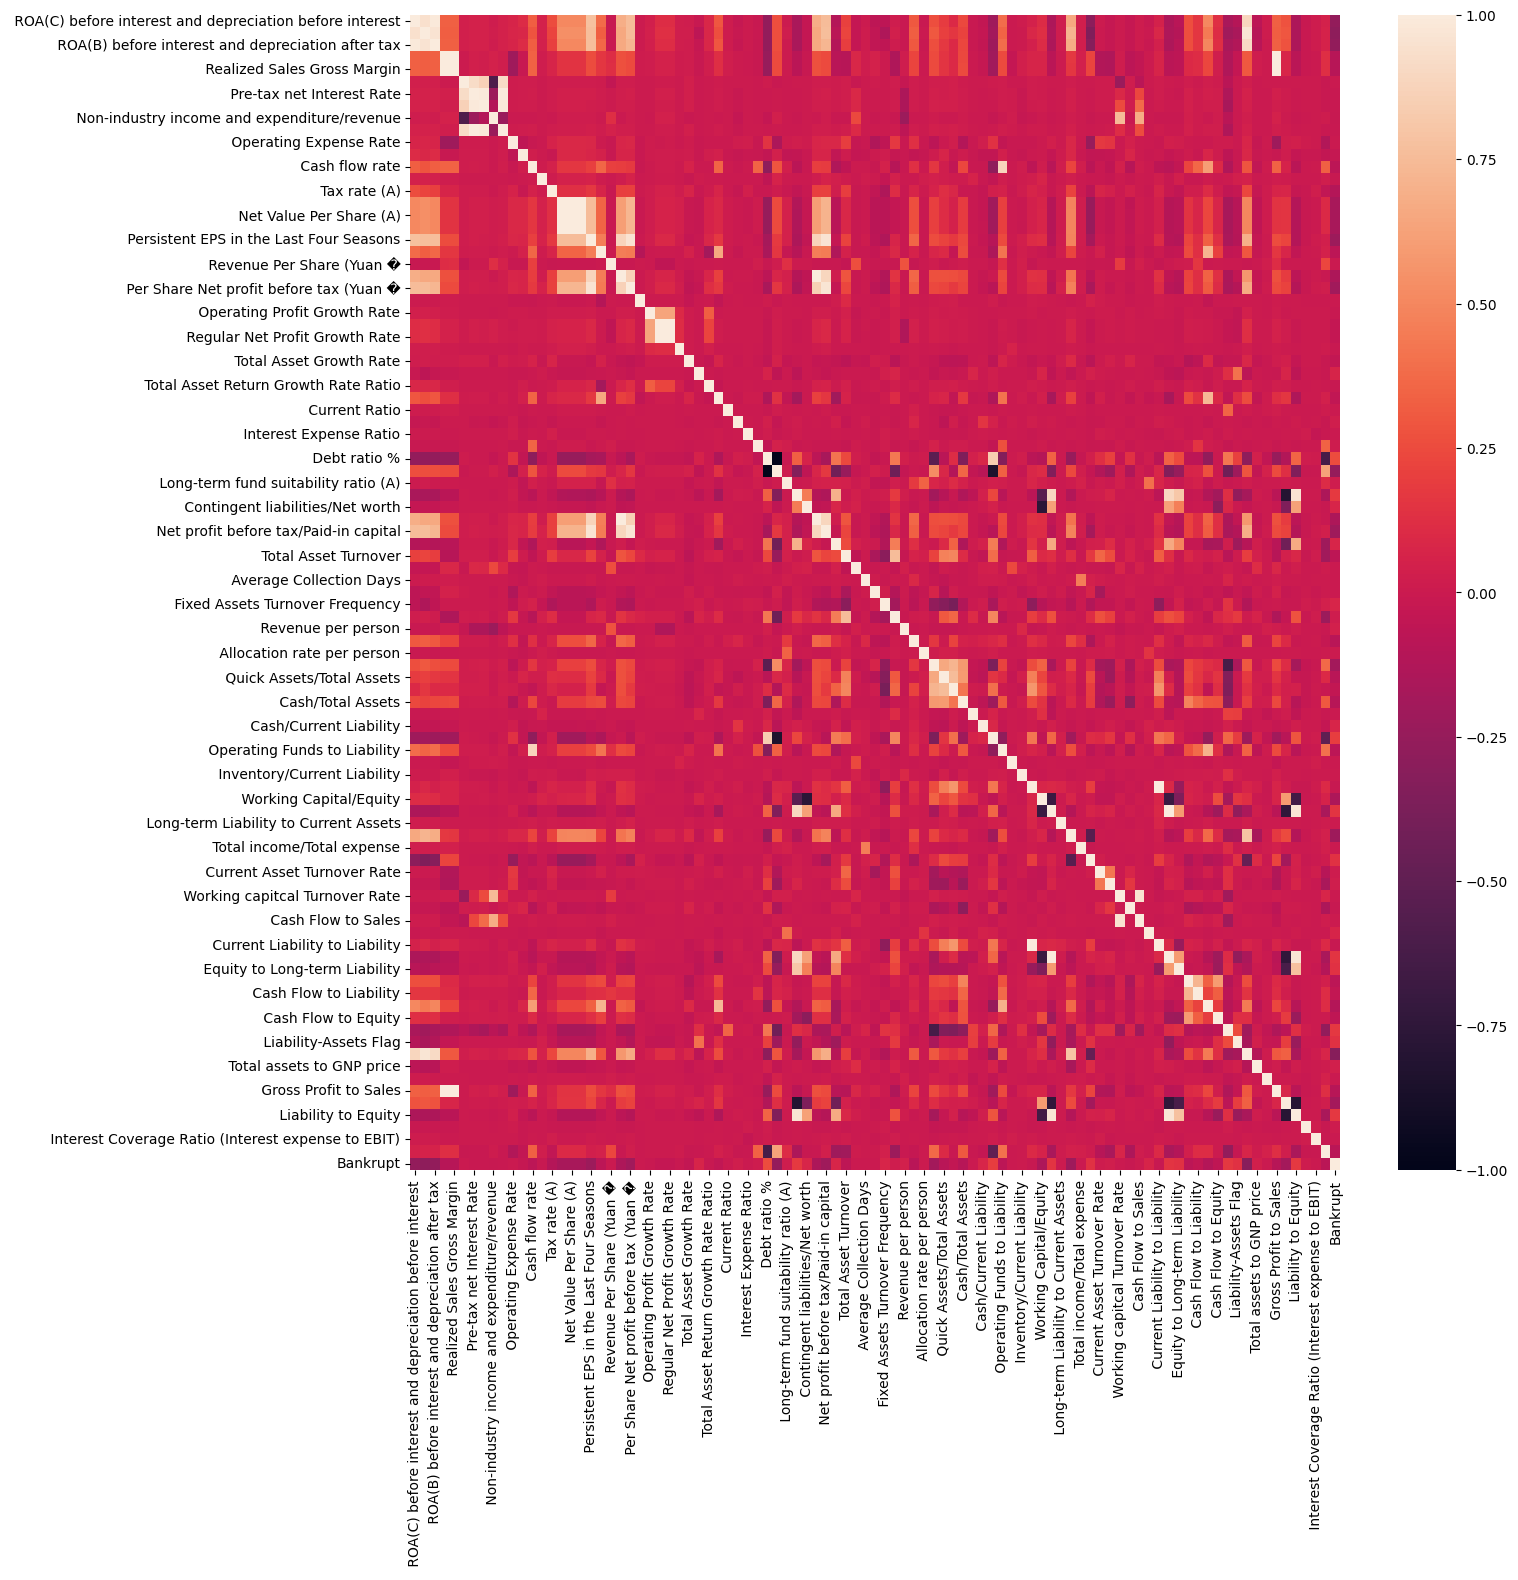

In [ ]:
plt.figure(figsize=(15,15))
data_corr = data.corr(method="spearman")
sns.heatmap(data.corr())
plt.show()

In [ ]:
# lets check with target column
target_corr_pearson = data.corr(method = "pearson")["Bankrupt"].sort_values()
target_corr_spearman = data.corr(method="spearman")["Bankrupt"].sort_values()
compare_corrs = pd.concat([target_corr_pearson,target_corr_spearman],axis=1)
compare_corrs.columns= ["pearson","spearman"]
compare_corrs

,pearson,spearman
Net Income to Total Assets,-0.315457,-0.234316
ROA(A) before interest and % after tax,-0.282941,-0.222410
ROA(B) before interest and depreciation after tax,-0.273051,-0.224163
ROA(C) before interest and depreciation before interest,-0.260807,-0.223589
Net worth/Assets,-0.250161,-0.217237
Persistent EPS in the Last Four Seasons,-0.219560,-0.238209
Retained Earnings to Total Assets,-0.217779,-0.229533
Net profit before tax/Paid-in capital,-0.207857,-0.233106
Per Share Net profit before tax (Yuan �,-0.201395,-0.232442
Working Capital to Total Assets,-0.193083,-0.173154


- Choosing spearman over pearson as we can see that quick ratio suppose to reduce the risk of bankruptcy but in pearson it is near 0 but in spearman it is negative correlated.
- so spearman can understand the monotonic relationship and also we have outliers.

In [ ]:
# Checking outliers

def outliers(data, col):
    median = data[col].quantile(0.50)
    Mean = data[col].mean()
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    IQR = q3 - q1
    upper_range = q3 + (1.5 * IQR)
    lower_range = q1 - (1.5 * IQR)
    upper_value_outliers = data[col] > upper_range
    lower_value_outliers = data[col] < lower_range

    upper_count = upper_value_outliers.sum()
    lower_count = lower_value_outliers.sum()
    total_count = upper_count + lower_count

    print(f"Column:{col}")
    print(f"Median:{median}")
    print(f"Average:{Mean}")
    print(f"Q1: {q1}")
    print(f"Q3:{q3}")
    print(f"IQR:{IQR}")
    print(f"Lower Range:{lower_range}")
    print(f"Upper Range: {upper_range}")
    print(f"Upper range outliers: {upper_count}")
    print(f"Lower range outliers: {lower_count}")
    print(f"Total outliers: {total_count}")

    outlier_result = pd.DataFrame({
        "COLUMN": [col],
        "Median":[median],
        "Mean":[Mean],
        "Q1": [q1],
        "Q3": [q3],
        "IQR": [IQR],
        "Lower Range": [lower_range],
        "Upper Range": [upper_range],
        "Total Outliers": [total_count]
    })

    return outlier_result



In [ ]:
# check outliers

for col in data.columns:
  outliers(data,col)
  print("=======================")

Column: ROA(C) before interest and depreciation before interest
Median:0.502705601
Average:0.5051796332387447
Q1: 0.47652708
Q3:0.535562814
IQR:0.05903573400000006
Lower Range:0.3879734789999999
Upper Range: 0.6241164150000001
Upper range outliers: 197
Lower range outliers: 194
Total outliers: 391
Column: ROA(A) before interest and % after tax
Median:0.55980157
Average:0.5586249158794545
Q1: 0.535542957
Q3:0.5891572174999999
IQR:0.053614260499999955
Lower Range:0.45512156625000005
Upper Range: 0.6695786082499999
Upper range outliers: 232
Lower range outliers: 329
Total outliers: 561
Column: ROA(B) before interest and depreciation after tax
Median:0.552277959
Average:0.553588709344332
Q1: 0.527276621
Q3:0.584105145
IQR:0.05682852400000005
Lower Range:0.4420338349999999
Upper Range: 0.6693479310000001
Upper range outliers: 191
Lower range outliers: 241
Total outliers: 432
Column: Operating Gross Margin
Median:0.605997492
Average:0.607948038371902
Q1: 0.600444659
Q3:0.6139141525
IQR:0.013

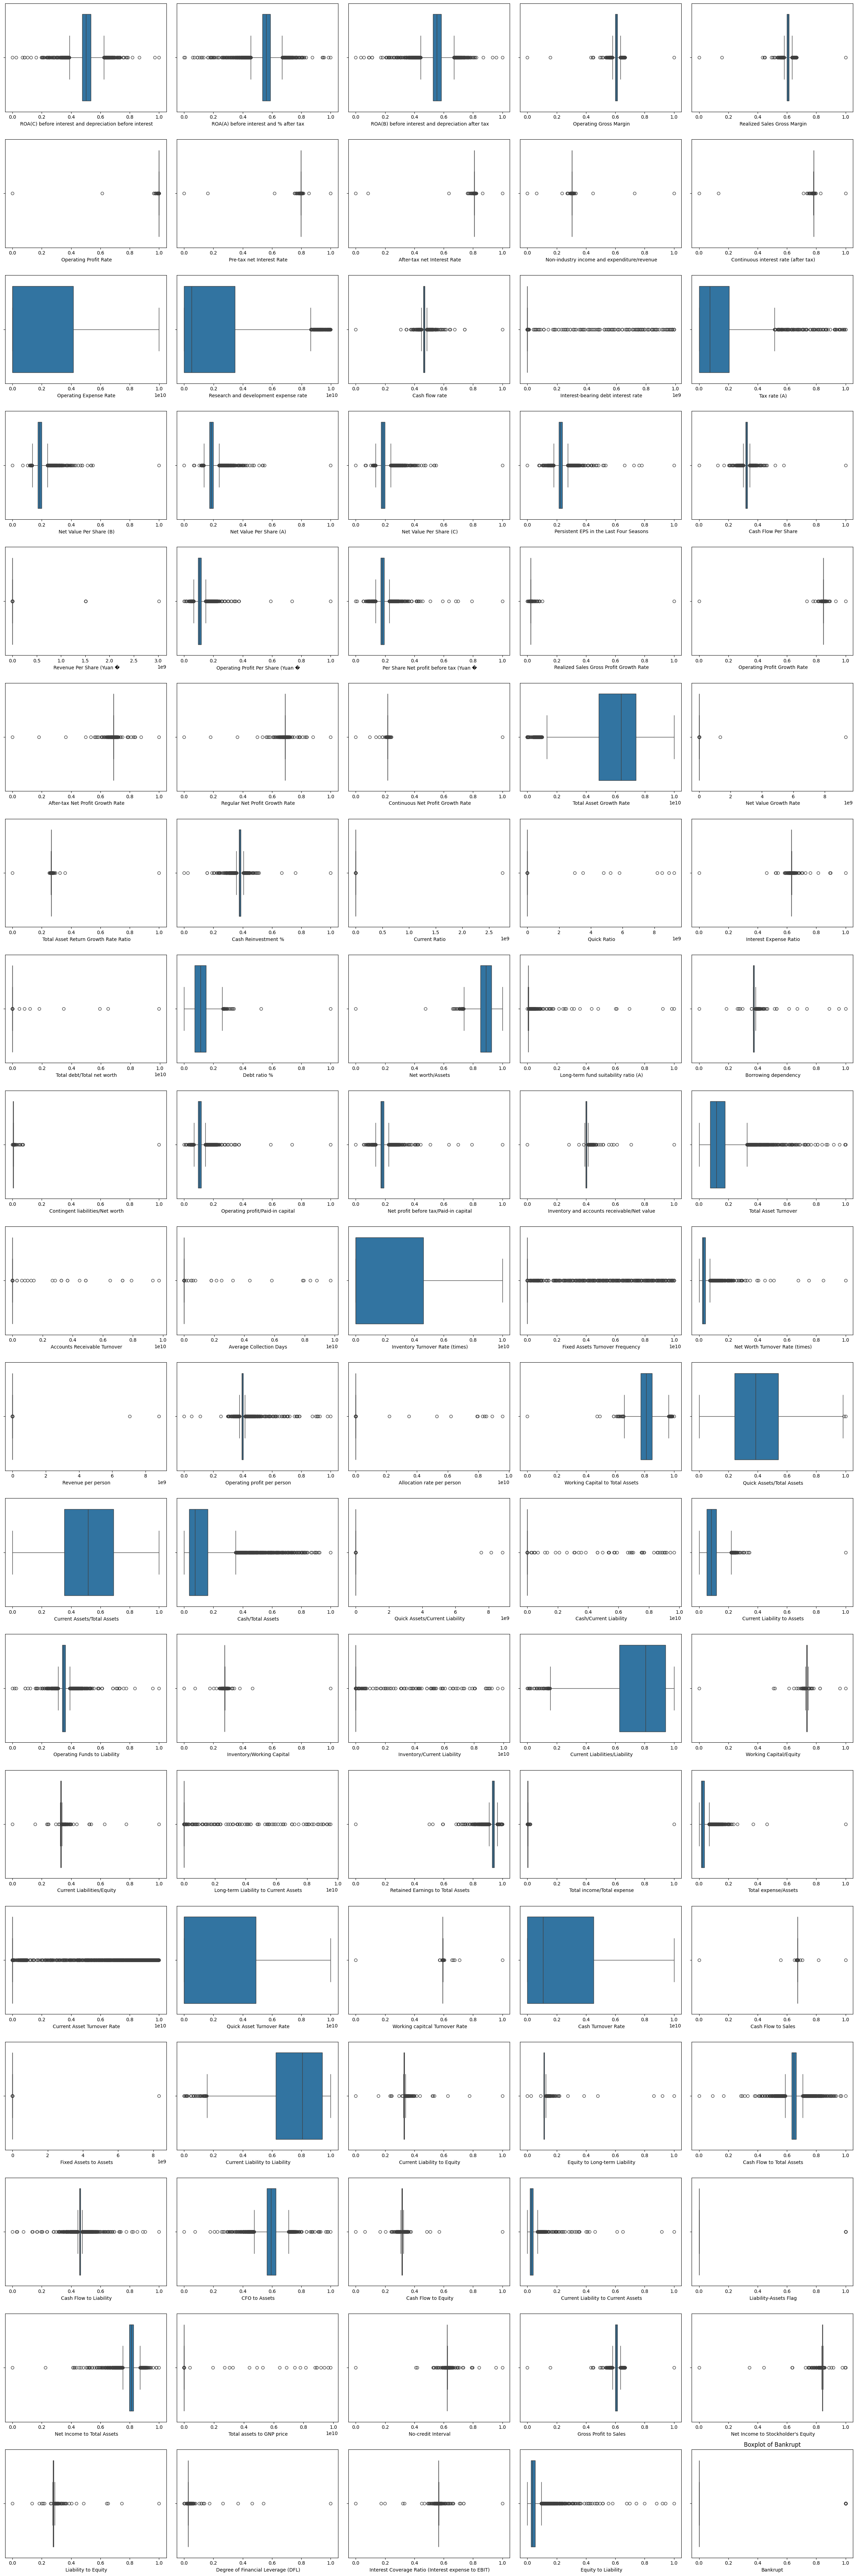

In [ ]:
# lets see the outliers in maps in boxplot
fig , axes = plt.subplots(19,5,figsize = (25,75))
axes = axes.flatten()

for i , col in enumerate(data.columns):
  sns.boxplot(data = data ,x = col , ax = axes[i] )
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


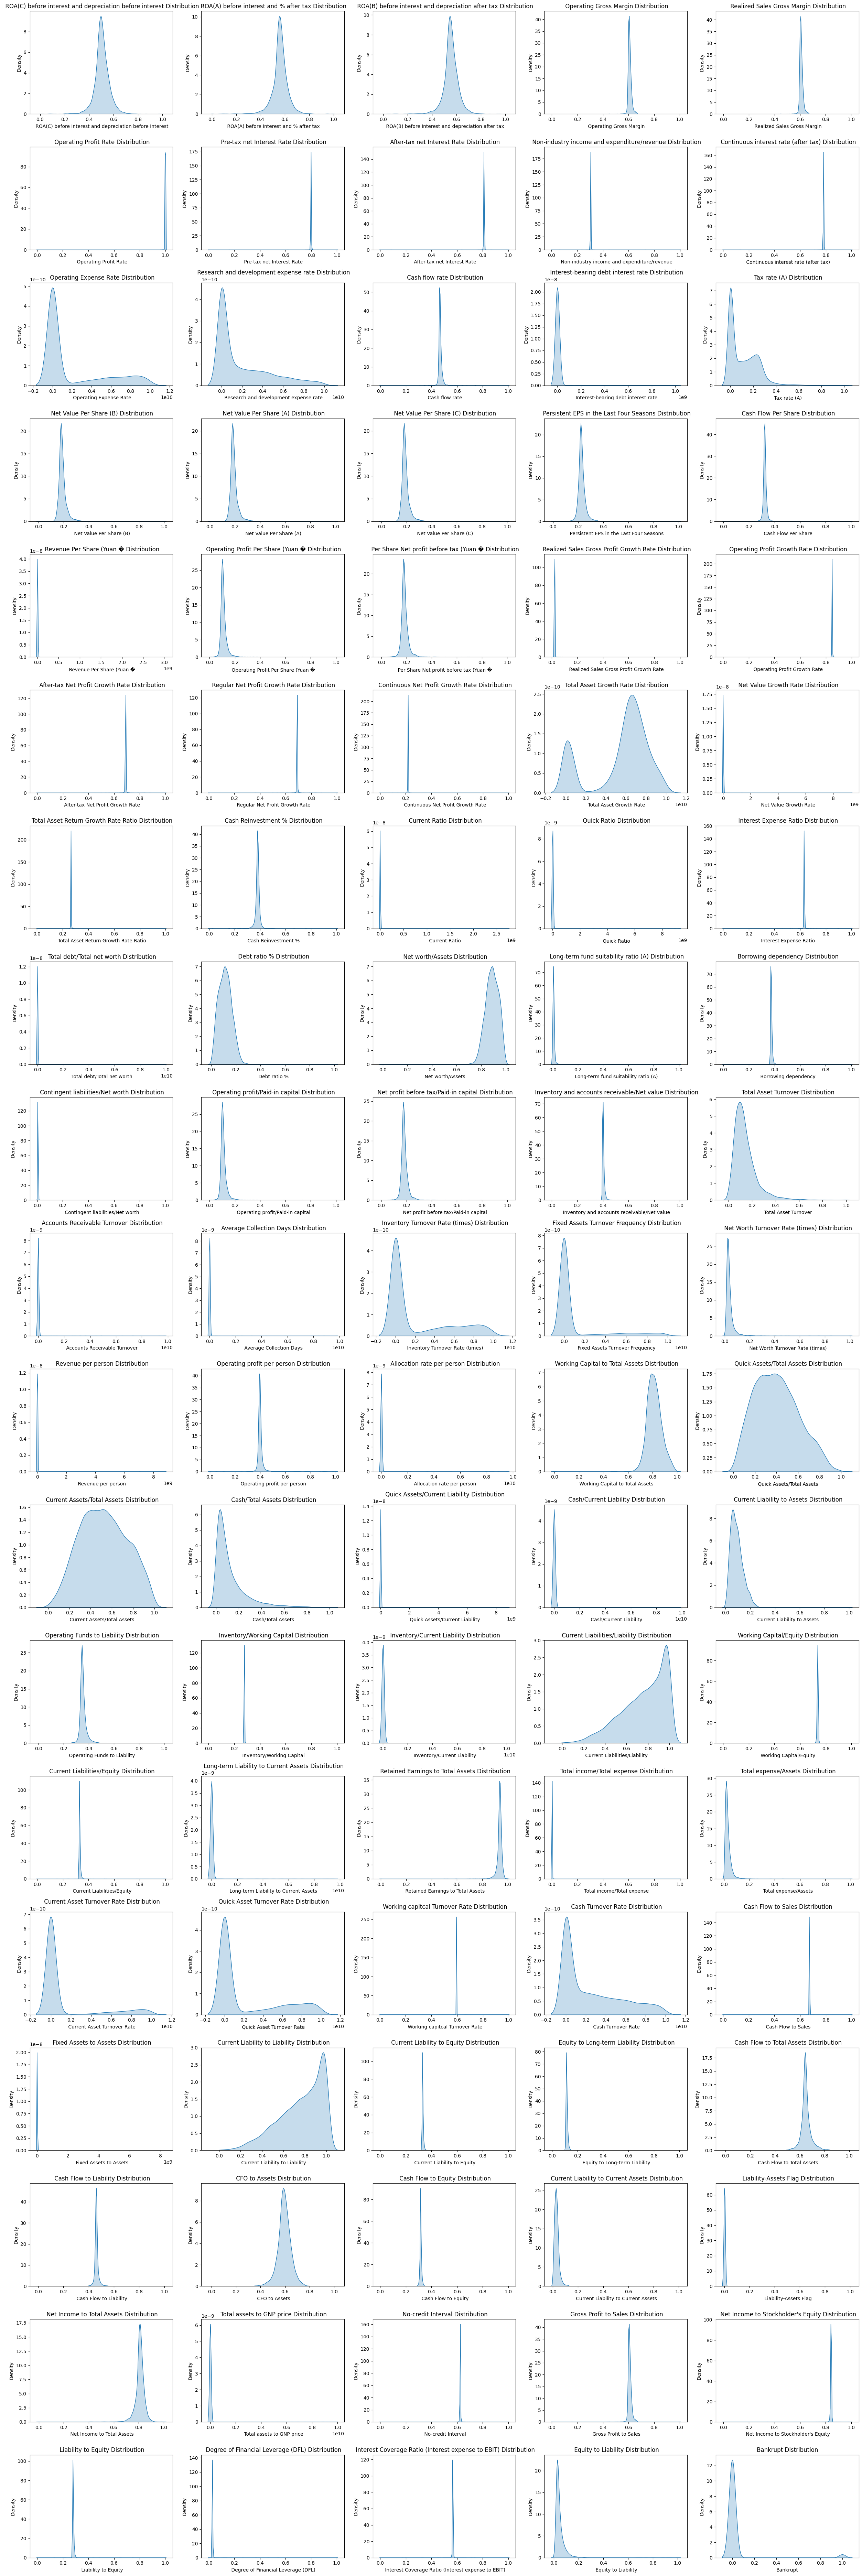

In [ ]:
# Visualize distributions
fig, axes = plt.subplots(19,5, figsize=(25,75))
axes = axes.flatten()

for i, col in enumerate(data.columns):
    sns.kdeplot(data=data, x=col, ax=axes[i], fill=True)
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# Functions
# cap_outliers(df, exclude_cols=['Bankrupt'])
# prepare_data(df, smote=False, scale=False)
# get_best_model(model_name, parameters, X_train, Y_train)
# metrics(actual, predicted)
# tuning_model(model, X_train, Y_train, X_test, Y_test)

In [ ]:
# treating outliers function

def cap_outliers(df, exclude_cols=['Bankrupt']):
    df_copy = df.copy()
    for col in df_copy.columns:
        if col in exclude_cols:
            continue
        q1 = df_copy[col].quantile(0.25)
        q3 = df_copy[col].quantile(0.75)
        IQR = q3 - q1
        lower_range = q1 - 1.5*IQR
        upper_range = q3 + 1.5*IQR
        df_copy[col] = df_copy[col].clip(lower=lower_range, upper=upper_range)
    return df_copy

In [ ]:
# data before and after treating outliers
data_with_outliers  = data.copy()
data_without_outliers = cap_outliers(data, exclude_cols=['Bankrupt'])

In [ ]:
# train test split
def prepare_data(df, smote=False, scale=False):
    X = df.drop(columns=['Bankrupt'])
    Y = df['Bankrupt']

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, stratify=Y, random_state=42
    )

    if smote:
        sm = SMOTE(random_state=42)
        X_train, Y_train = sm.fit_resample(X_train, Y_train)

    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, Y_train, Y_test

In [ ]:
# Random Search CV
def get_best_model(model_name, parameters, X_train, Y_train):
    random_search_cv = RandomizedSearchCV(
        estimator=model_name,
        param_distributions=parameters,
        n_jobs=-1,
        n_iter=10,
        cv=5,
        random_state=42
    )
    print("Model started fitting...")
    random_search_cv.fit(X_train, Y_train)
    best_parameters = random_search_cv.best_params_
    best_model = random_search_cv.best_estimator_
    print("Model finished fitting")
    print(f"Best Model: {best_model}")
    print(f"Best Parameters: {best_parameters}")
    return best_parameters, best_model


In [ ]:
# Metrics
def metrics(actual, predicted):
    cm = confusion_matrix(actual, predicted)
    roc_auc = roc_auc_score(actual, predicted)
    f1 = f1_score(actual, predicted)
    acc = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)

    print(f"roc_auc_score: {roc_auc}")
    print(f"precision: {precision}")
    print(f"recall: {recall}")
    print(f"f1-score: {f1}")
    print(f"accuracy: {acc}")
    print(f"confusionmatrix:\n{cm}")

    return cm, roc_auc, f1, acc

In [ ]:
# Fit model + show metrics
def tuning_model(model, X_train, Y_train, X_test, Y_test):
    print("Model started fitting...")
    model.fit(X_train, Y_train)
    print("Model finished fitting")
    pred = model.predict(X_test)
    return metrics(Y_test, pred)

In [ ]:
# Random Forest
Rf_base_model = RandomForestClassifier(class_weight="balanced")
Rf_base_params = {
    "n_estimators": [50,100,150,200],
    "max_depth": [None,2,4,6,8,10],
    "criterion": ["gini","entropy"],
    "min_samples_split": [2,4,6,8,10],
    "min_samples_leaf": [1,2,4,5]
}


In [ ]:

# XGBoost
xgb_base_model = XGBClassifier(scale_pos_weight=10)
xgb_base_params = {
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7],
    'n_estimators':[100,200,300],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1],
    'scale_pos_weight':[10,20,30]
}



In [ ]:
# Logistic Regression
logreg_base_model = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg_base_params = {
    'penalty': ['l1','l2','elasticnet', None],
    'solver': ['liblinear','saga'],
    'C': [0.01,0.1,1,10,100],
    'l1_ratio': [0,0.5,1]
}

##1. WITH OUTLIERS + NO SCALE + NO SMOTE

In [ ]:
# With outliers and without SMOTE/Scaling
X_train, X_test, Y_train, Y_test = prepare_data(data_with_outliers, smote=False, scale=False)

In [ ]:
print("=== RANDOM FOREST ===")
# Get best parameters and model
rf_best_parameters, rf_best_model = get_best_model(Rf_base_model, Rf_base_params, X_train, Y_train)

# Train and evaluate
rf_confusion_matrix, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(rf_best_model, X_train, Y_train, X_test, Y_test)

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
Best Model: RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_split=8)
Best Parameters: {'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}
Model started fitting...
Model finished fitting
roc_auc_score: 0.7621212121212121
precision: 0.46153846153846156
recall: 0.5454545454545454
f1-score: 0.5
accuracy: 0.9648093841642229
confusionmatrix:
[[1292   28]
 [  20   24]]


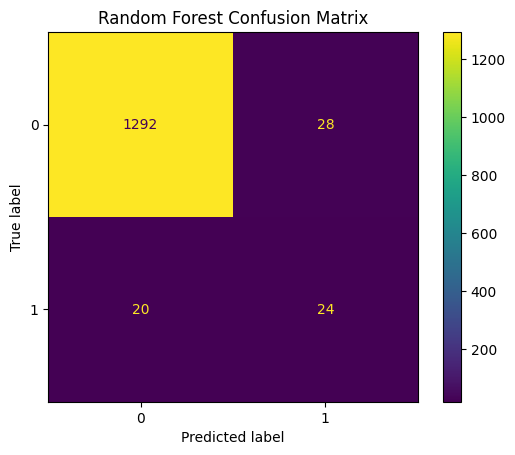

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("=== XGBOOST ===")
# Get best parameters and model
xgb_best_parameters, xgb_best_model = get_best_model(xgb_base_model, xgb_base_params, X_train, Y_train)

# Train and evaluate
xgb_confusion_matrix, xgb_roc_auc, xgb_f1_score, xgb_accuracy = tuning_model(xgb_best_model, X_train, Y_train, X_test, Y_test)

=== XGBOOST ===
Model started fitting...
Model finished fitting
Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Model started fitting...


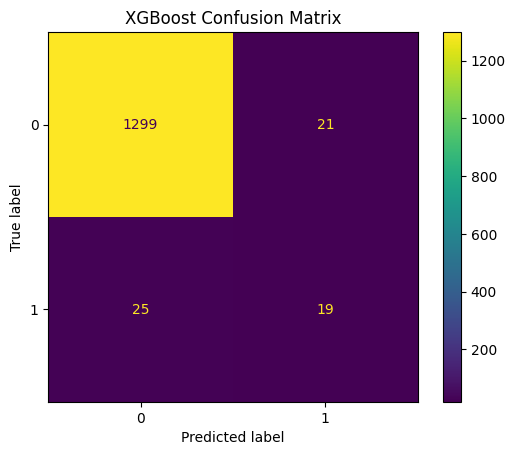

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
# Get best parameters and model
logreg_best_parameters, logreg_best_model = get_best_model(logreg_base_model, logreg_base_params, X_train, Y_train)

# Train and evaluate
logreg_confusion_matrix, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(logreg_best_model, X_train, Y_train, X_test, Y_test)

=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
Best Model: LogisticRegression(C=1, class_weight='balanced', l1_ratio=1, max_iter=1000,
                   penalty='l1', solver='liblinear')
Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'l1_ratio': 1, 'C': 1}
Model started fitting...
Model finished fitting
roc_auc_score: 0.8568181818181819
precision: 0.18048780487804877
recall: 0.8409090909090909
f1-score: 0.2971887550200803
accuracy: 0.8717008797653959
confusionmatrix:
[[1152  168]
 [   7   37]]


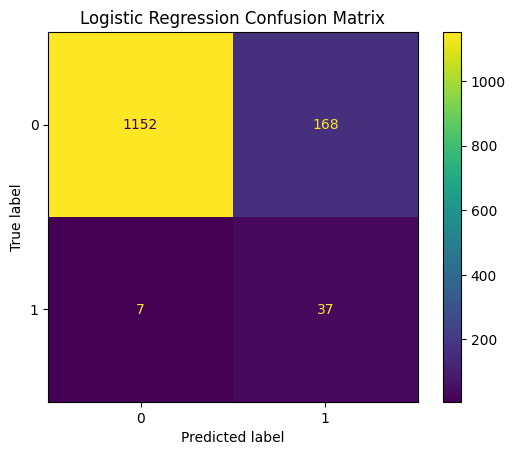

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

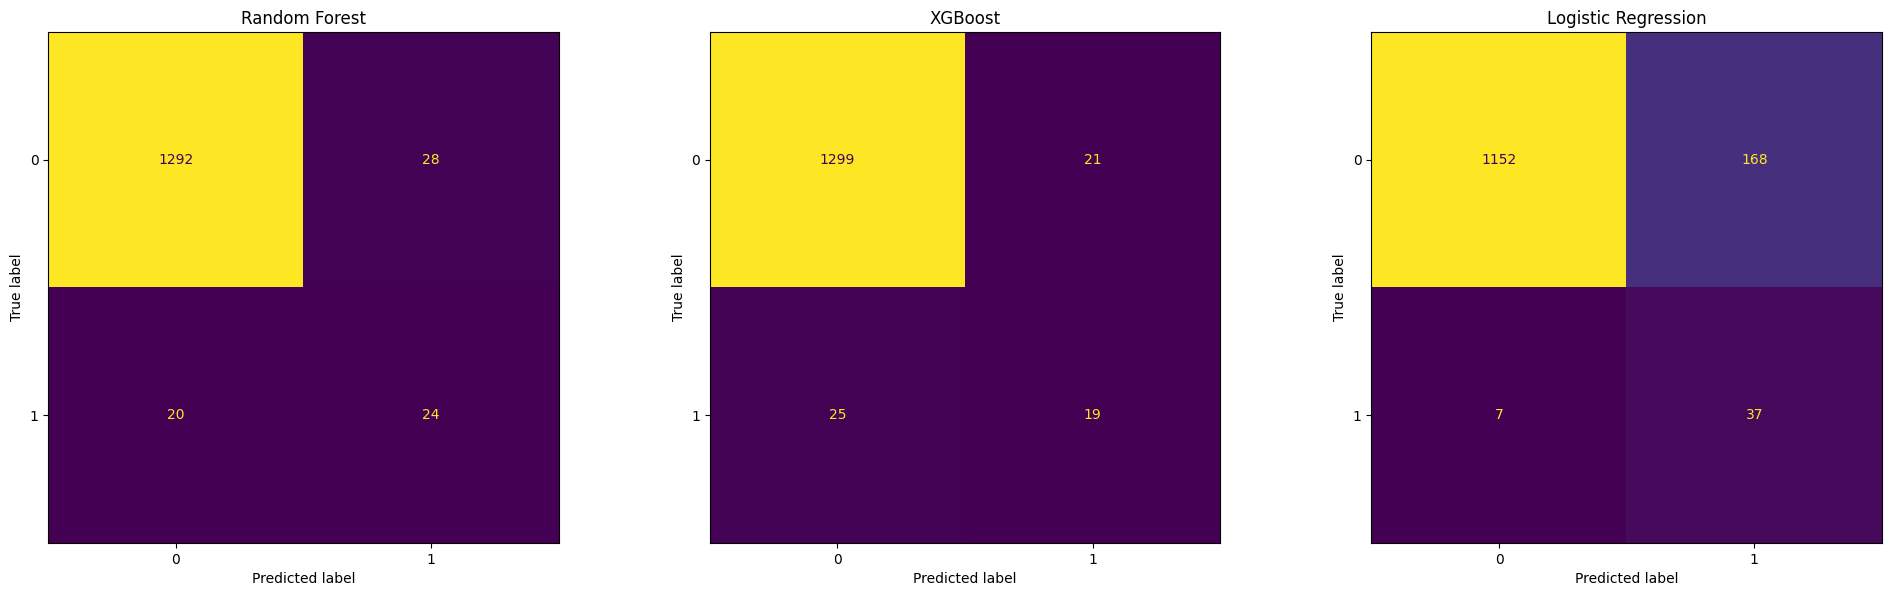

In [ ]:
# Plot all confusion matrices in one figure
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp_logreg.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

#### MODEL AND BEST PARAMETERS
- RandomForestClassifier(n_estimators = 100 ,class_weight='balanced', criterion='entropy', max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

- XGBClassifier(subsample = 0.8, scale_pos_weight=  10, n_estimators=200, max_depth = 5, learning_rate = 0.1, colsample_bytree = 0.8)

- LogisticRegression(C=1, class_weight='balanced', l1_ratio=1, max_iter=1000,penalty='l1', solver='liblinear')



##2. WITH OUTLIERS + WITH SCALE + NO SMOTE

In [ ]:
# With outliers and without SMOTE/Scaling
X_train, X_test, Y_train, Y_test = prepare_data(data_with_outliers, smote=False, scale=True)

In [ ]:
print("=== RANDOM FOREST ===")
Rf_with_outliers_withscale_nosmote = RandomForestClassifier(n_estimators = 100 ,class_weight='balanced', criterion='entropy',
                                                           max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

# Train and evaluate
rf_confusion_matrix, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(Rf_with_outliers_withscale_nosmote, X_train, Y_train, X_test, Y_test)

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.7295454545454545
precision: 0.4666666666666667
recall: 0.4772727272727273
f1-score: 0.47191011235955055
accuracy: 0.9655425219941349
confusionmatrix:
[[1296   24]
 [  23   21]]


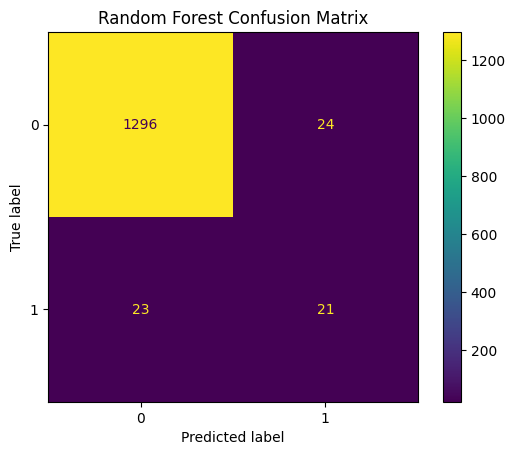

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("=== XGBOOST ===")
# Get best parameters and model
XGB_with_outliers_withscale_nosmote = XGBClassifier(subsample = 0.8, scale_pos_weight= 10, n_estimators=200, max_depth = 5,
                                                    learning_rate = 0.1, colsample_bytree = 0.8)

# Train and evaluate
xgb_confusion_matrix, xgb_roc_auc, xgb_f1_score, xgb_accuracy = tuning_model(XGB_with_outliers_withscale_nosmote, X_train, Y_train, X_test, Y_test)

=== XGBOOST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.7208333333333333
precision: 0.5405405405405406
recall: 0.45454545454545453
f1-score: 0.49382716049382713
accuracy: 0.9699413489736071
confusionmatrix:
[[1303   17]
 [  24   20]]


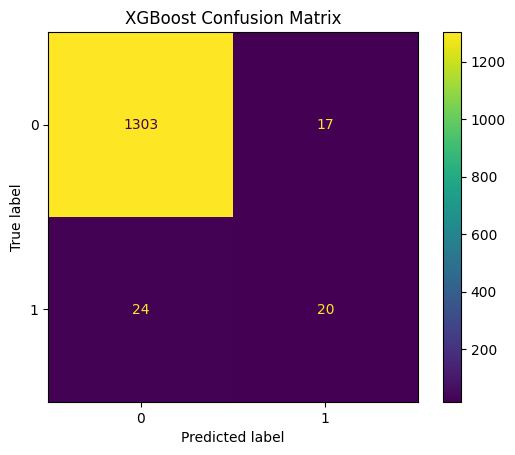

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
# Get best parameters and model
logreg_with_outliers_withscale_nosmote = LogisticRegression(C=1, class_weight='balanced', l1_ratio=1,
                                                               max_iter=1000,penalty='l1', solver='liblinear')

# Train and evaluate
logreg_confusion_matrix, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(logreg_with_outliers_withscale_nosmote, X_train, Y_train, X_test, Y_test)

=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8507575757575758
precision: 0.18947368421052632
recall: 0.8181818181818182
f1-score: 0.3076923076923077
accuracy: 0.8812316715542522
confusionmatrix:
[[1166  154]
 [   8   36]]


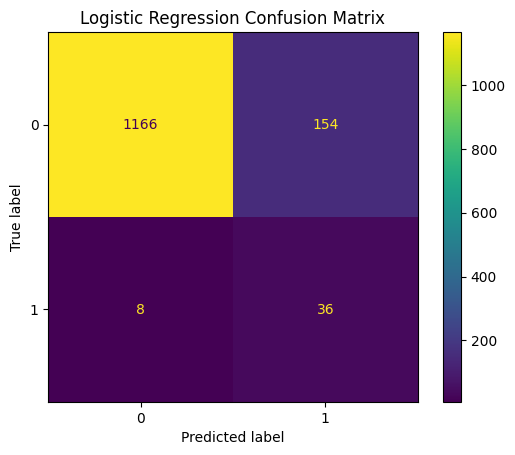

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

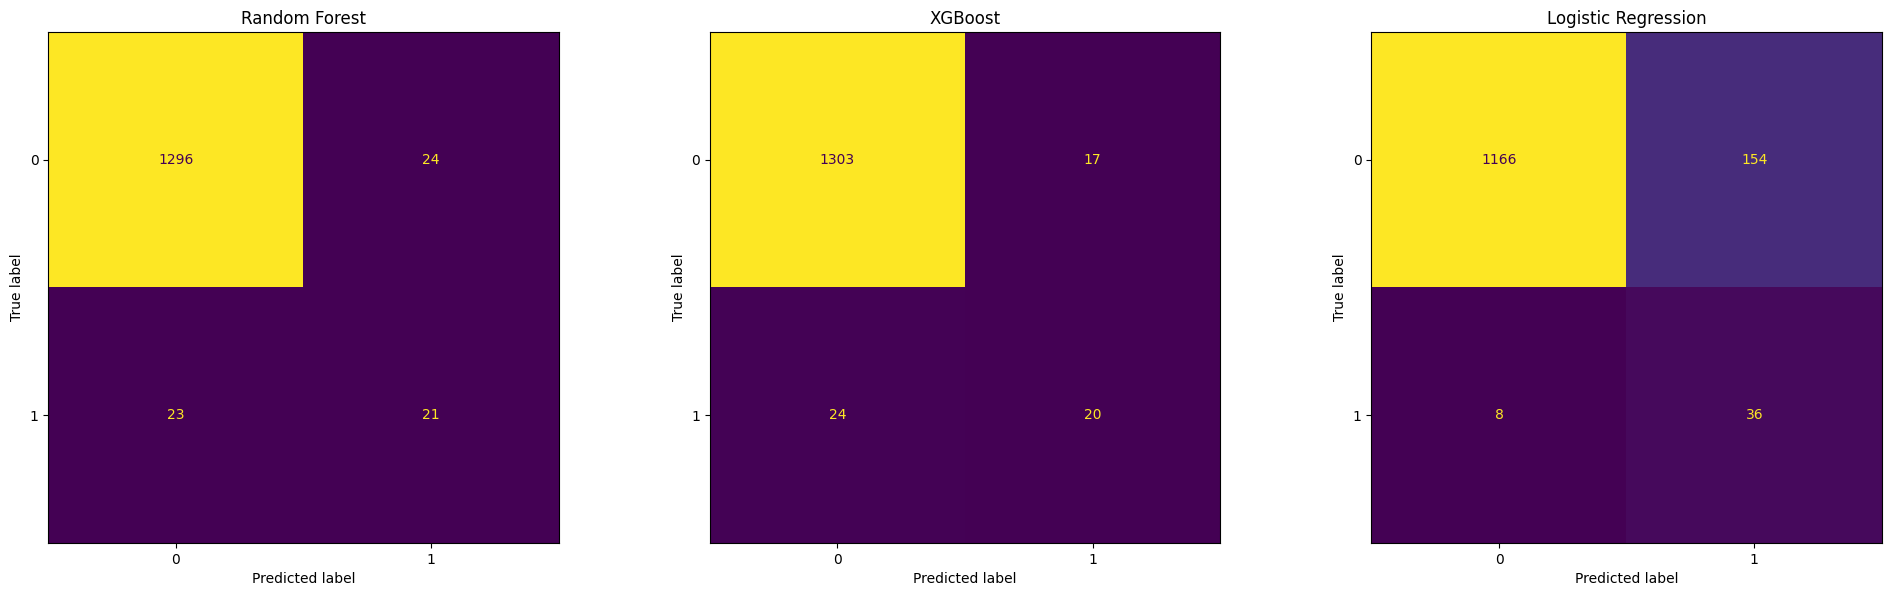

In [ ]:
# Plot all confusion matrices in one figure
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp_logreg.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

##3. WITH OUTLIERS + WITH SCALE + WITH SMOTE

In [ ]:
# With outliers and without SMOTE/Scaling
X_train, X_test, Y_train, Y_test = prepare_data(data_with_outliers, smote=True, scale=True)

In [ ]:
print("=== RANDOM FOREST ===")
Rf_with_outliers_withscale_withsmote = RandomForestClassifier(n_estimators = 100 ,class_weight='balanced', criterion='entropy',
                                                           max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

# Train and evaluate
rf_confusion_matrix, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(Rf_with_outliers_withscale_withsmote, X_train, Y_train, X_test, Y_test)

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8602272727272727
precision: 0.3300970873786408
recall: 0.7727272727272727
f1-score: 0.46258503401360546
accuracy: 0.9420821114369502
confusionmatrix:
[[1251   69]
 [  10   34]]


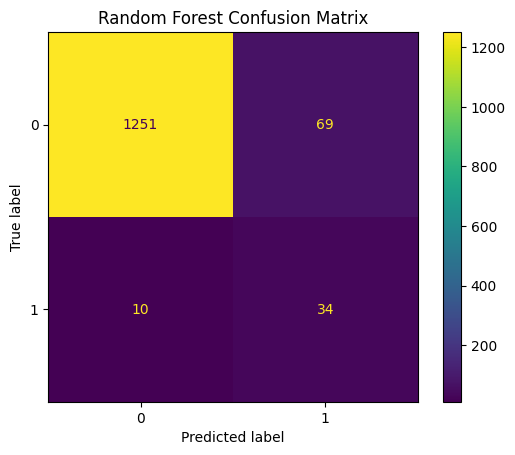

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("=== XGBOOST ===")
# Get best parameters and model
XGB_with_outliers_withscale_withsmote = XGBClassifier(subsample = 0.8, scale_pos_weight= 10, n_estimators=200, max_depth = 5,
                                                    learning_rate = 0.1, colsample_bytree = 0.8)

# Train and evaluate
xgb_confusion_matrix, xgb_roc_auc, xgb_f1_score, xgb_accuracy = tuning_model(XGB_with_outliers_withscale_withsmote, X_train, Y_train, X_test, Y_test)

=== XGBOOST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.7992424242424242
precision: 0.358974358974359
recall: 0.6363636363636364
f1-score: 0.45901639344262296
accuracy: 0.9516129032258065
confusionmatrix:
[[1270   50]
 [  16   28]]


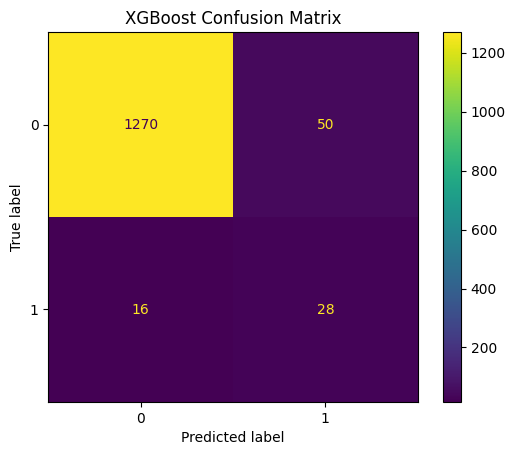

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
# Get best parameters and model
logreg_with_outliers_withscale_withsmote = LogisticRegression(C=1, class_weight='balanced', l1_ratio=1,
                                                               max_iter=1000,penalty='l1', solver='liblinear')

# Train and evaluate
logreg_confusion_matrix, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(logreg_with_outliers_withscale_withsmote, X_train, Y_train, X_test, Y_test)

=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8151515151515153
precision: 0.2
recall: 0.7272727272727273
f1-score: 0.3137254901960784
accuracy: 0.8973607038123167
confusionmatrix:
[[1192  128]
 [  12   32]]


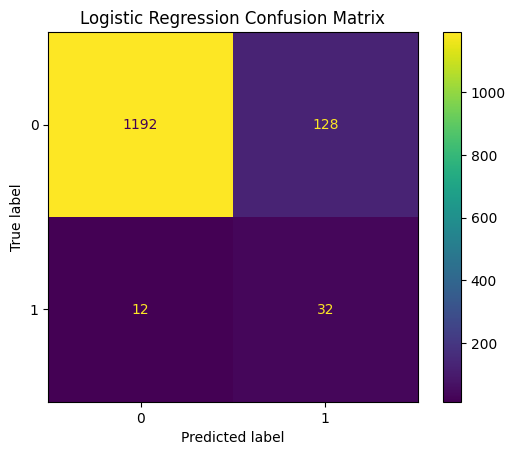

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

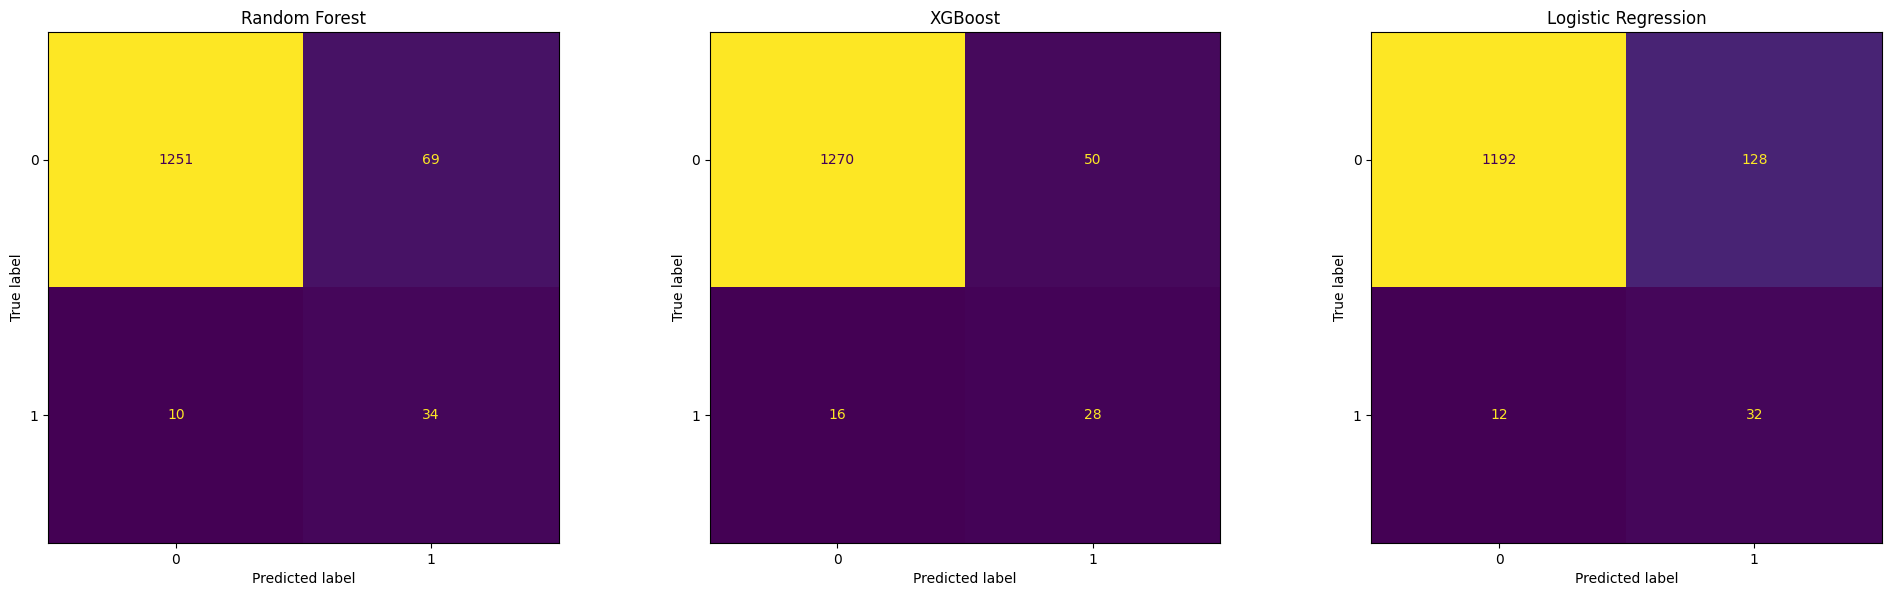

In [ ]:
# Plot all confusion matrices in one figure
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp_logreg.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

##4. WITH OUT OUTLIERS + NO SCALE + NO SMOTE

In [ ]:
# With outliers and without SMOTE/Scaling
X_train, X_test, Y_train, Y_test = prepare_data(data_without_outliers, smote=False, scale=False)

In [ ]:
print("=== RANDOM FOREST ===")
Rf_without_outliers_noscale_nosmote = RandomForestClassifier(n_estimators = 100 ,class_weight='balanced', criterion='entropy',
                                                           max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

# Train and evaluate
rf_confusion_matrix, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(Rf_without_outliers_noscale_nosmote, X_train, Y_train, X_test, Y_test)

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.7295454545454545
precision: 0.4666666666666667
recall: 0.4772727272727273
f1-score: 0.47191011235955055
accuracy: 0.9655425219941349
confusionmatrix:
[[1296   24]
 [  23   21]]


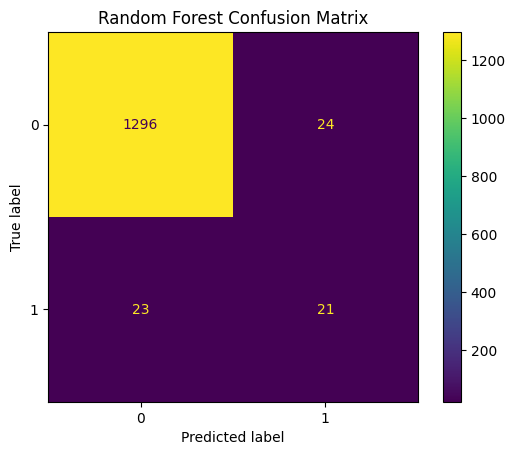

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("=== XGBOOST ===")
# Get best parameters and model
XGB_without_outliers_noscale_nosmote = XGBClassifier(subsample = 0.8, scale_pos_weight= 10, n_estimators=200, max_depth = 5,
                                                    learning_rate = 0.1, colsample_bytree = 0.8)

# Train and evaluate
xgb_confusion_matrix, xgb_roc_auc, xgb_f1_score, xgb_accuracy = tuning_model(XGB_without_outliers_noscale_nosmote, X_train, Y_train, X_test, Y_test)

=== XGBOOST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.6874999999999999
precision: 0.53125
recall: 0.38636363636363635
f1-score: 0.4473684210526316
accuracy: 0.969208211143695
confusionmatrix:
[[1305   15]
 [  27   17]]


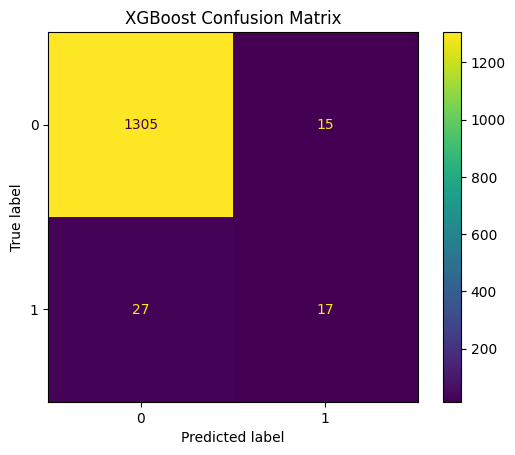

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
# Get best parameters and model
logreg_without_outliers_noscale_nosmote = LogisticRegression(C=1, class_weight='balanced', l1_ratio=1,
                                                               max_iter=1000,penalty='l1', solver='liblinear')

# Train and evaluate
logreg_confusion_matrix, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(logreg_without_outliers_noscale_nosmote, X_train, Y_train, X_test, Y_test)

=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8791666666666665
precision: 0.1875
recall: 0.8863636363636364
f1-score: 0.30952380952380953
accuracy: 0.8724340175953079
confusionmatrix:
[[1151  169]
 [   5   39]]


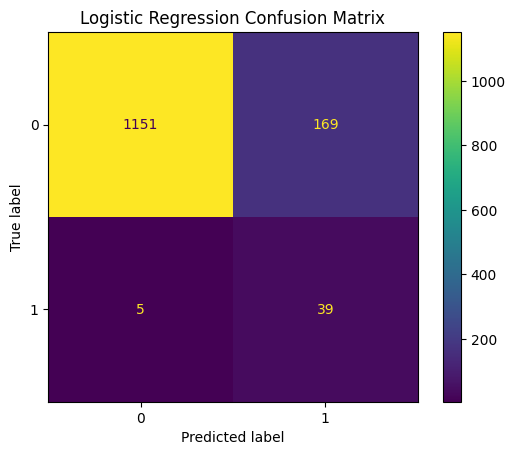

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

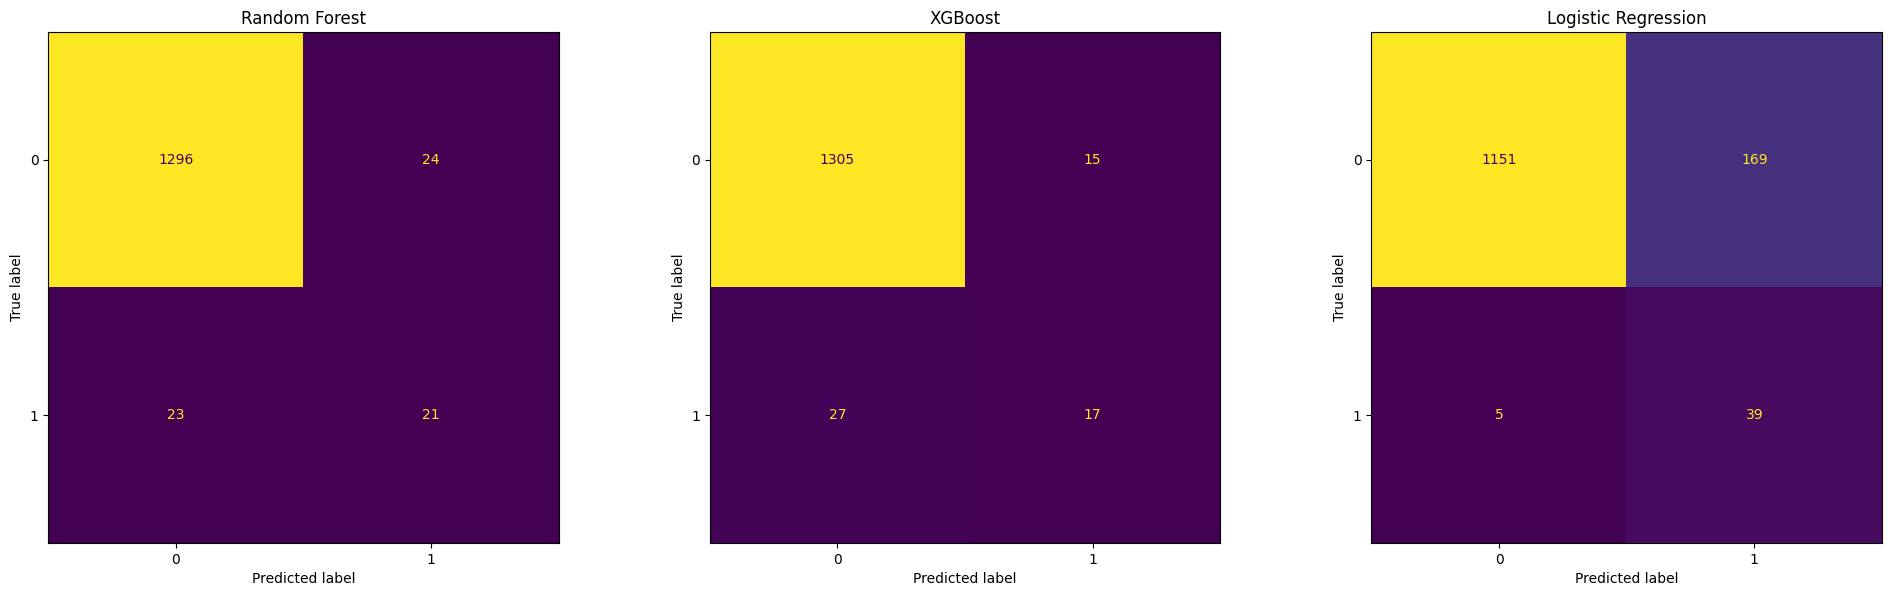

In [ ]:
# Plot all confusion matrices in one figure
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp_logreg.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

##5. WITH OUT OUTLIERS + WITH SCALE + NO SMOTE

In [ ]:
# With outliers and without SMOTE/Scaling
X_train, X_test, Y_train, Y_test = prepare_data(data_without_outliers, smote=False, scale=True)

In [ ]:
print("=== RANDOM FOREST ===")
Rf_without_outliers_withscale_nosmote = RandomForestClassifier(n_estimators = 100 ,class_weight='balanced', criterion='entropy',
                                                           max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

# Train and evaluate
rf_confusion_matrix, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(Rf_without_outliers_withscale_nosmote, X_train, Y_train, X_test, Y_test)

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.7287878787878789
precision: 0.44680851063829785
recall: 0.4772727272727273
f1-score: 0.46153846153846156
accuracy: 0.9640762463343109
confusionmatrix:
[[1294   26]
 [  23   21]]


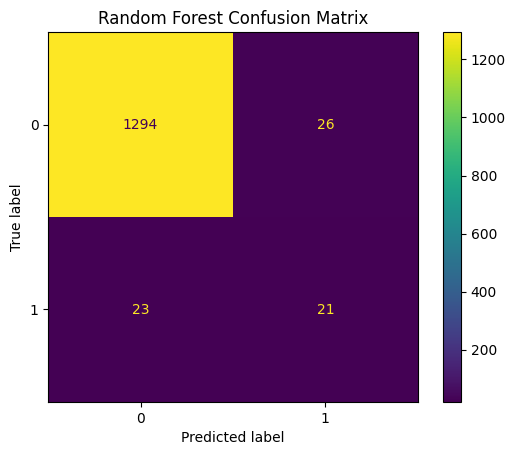

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("=== XGBOOST ===")
# Get best parameters and model
XGB_without_outliers_withscale_nosmote = XGBClassifier(subsample = 0.8, scale_pos_weight= 10, n_estimators=200, max_depth = 5,
                                                    learning_rate = 0.1, colsample_bytree = 0.8)

# Train and evaluate
xgb_confusion_matrix, xgb_roc_auc, xgb_f1_score, xgb_accuracy = tuning_model(XGB_without_outliers_withscale_nosmote, X_train, Y_train, X_test, Y_test)

=== XGBOOST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.6977272727272728
precision: 0.5
recall: 0.4090909090909091
f1-score: 0.45
accuracy: 0.967741935483871
confusionmatrix:
[[1302   18]
 [  26   18]]


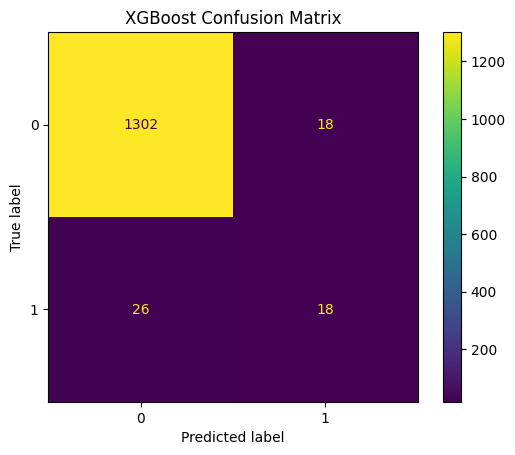

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
# Get best parameters and model
logreg_without_outliers_withscale_nosmote = LogisticRegression(C=1, class_weight='balanced', l1_ratio=1,
                                                               max_iter=1000,penalty='l1', solver='liblinear')

# Train and evaluate
logreg_confusion_matrix, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(logreg_without_outliers_withscale_nosmote, X_train, Y_train, X_test, Y_test)

=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8530303030303032
precision: 0.1956521739130435
recall: 0.8181818181818182
f1-score: 0.3157894736842105
accuracy: 0.8856304985337243
confusionmatrix:
[[1172  148]
 [   8   36]]


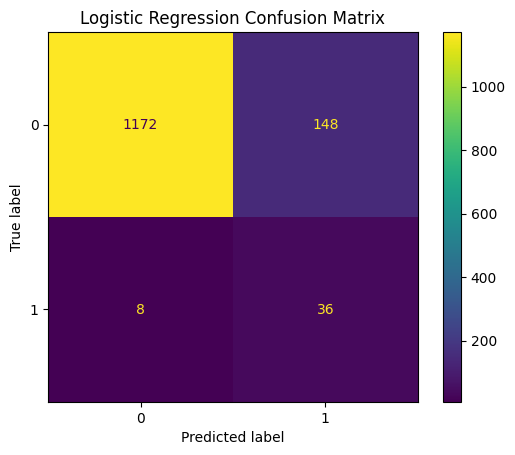

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

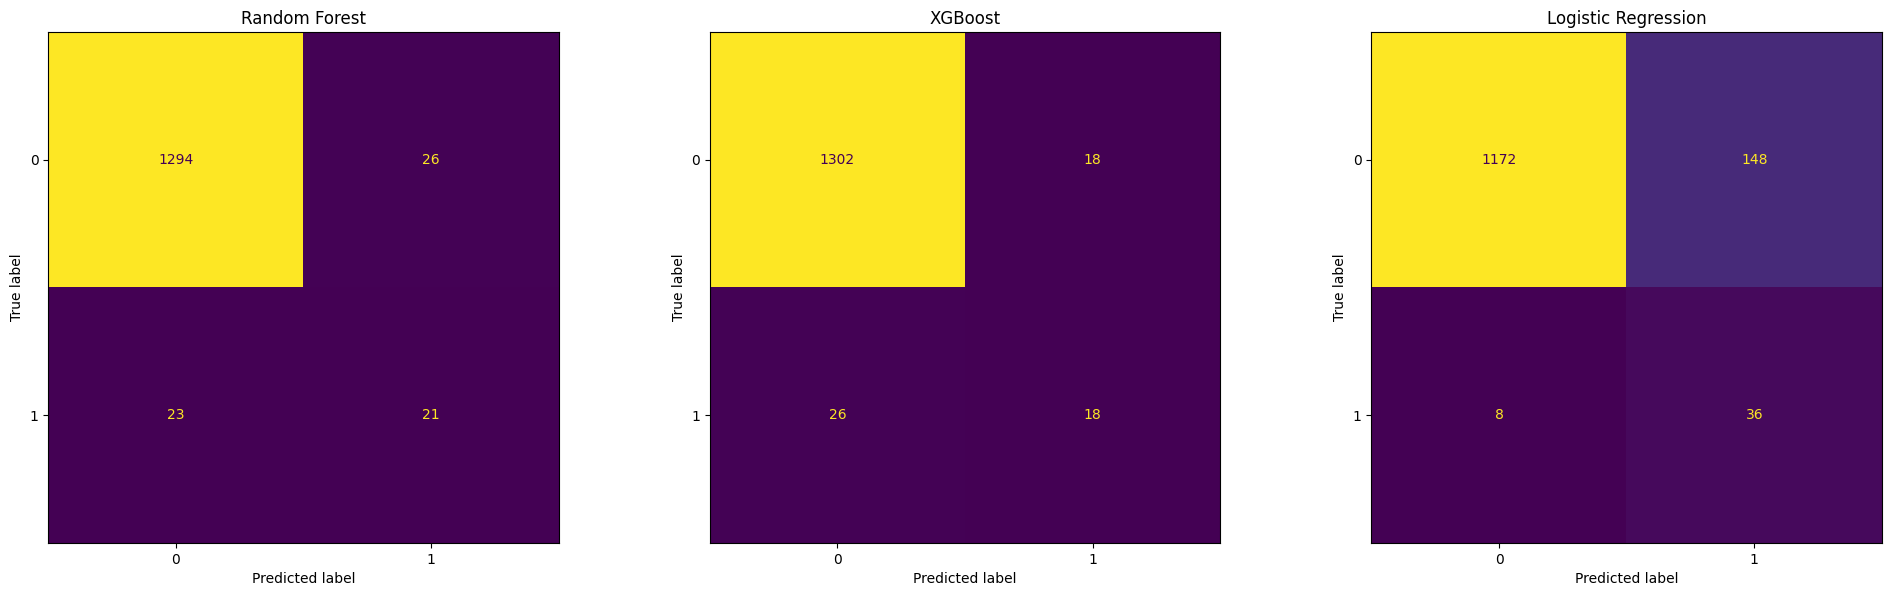

In [ ]:
# Plot all confusion matrices in one figure
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp_logreg.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

##6. WITH OUT OUTLIERS + WITH SCALE + WITH SMOTE

In [ ]:
# With outliers and without SMOTE/Scaling
X_train, X_test, Y_train, Y_test = prepare_data(data_without_outliers, smote=True, scale=True)

In [ ]:
print("=== RANDOM FOREST ===")
Rf_without_outliers_withscale_withsmote = RandomForestClassifier(n_estimators = 100 ,class_weight='balanced', criterion='entropy',
                                                           max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

# Train and evaluate
rf_confusion_matrix, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(Rf_without_outliers_withscale_withsmote, X_train, Y_train, X_test, Y_test)

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8098484848484849
precision: 0.35802469135802467
recall: 0.6590909090909091
f1-score: 0.464
accuracy: 0.9508797653958945
confusionmatrix:
[[1268   52]
 [  15   29]]


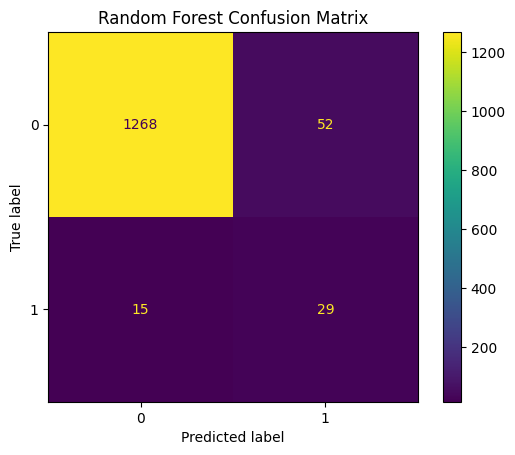

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("=== XGBOOST ===")
# Get best parameters and model
XGB_without_outliers_withscale_withsmote = XGBClassifier(subsample = 0.8, scale_pos_weight= 10, n_estimators=200, max_depth = 5,
                                                    learning_rate = 0.1, colsample_bytree = 0.8)

# Train and evaluate
xgb_confusion_matrix, xgb_roc_auc, xgb_f1_score, xgb_accuracy = tuning_model(XGB_without_outliers_withscale_withsmote, X_train, Y_train, X_test, Y_test)

=== XGBOOST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.768939393939394
precision: 0.38461538461538464
recall: 0.5681818181818182
f1-score: 0.45871559633027525
accuracy: 0.9567448680351907
confusionmatrix:
[[1280   40]
 [  19   25]]


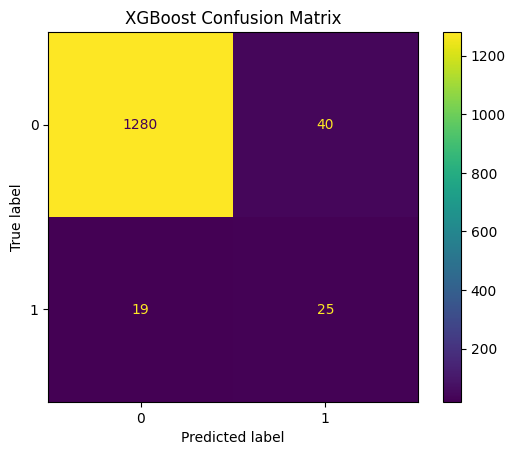

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
# Get best parameters and model
logreg_without_outliers_withscale_withsmote = LogisticRegression(C=1, class_weight='balanced', l1_ratio=1,
                                                               max_iter=1000,penalty='l1', solver='liblinear')

# Train and evaluate
logreg_confusion_matrix, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(logreg_without_outliers_withscale_withsmote, X_train, Y_train, X_test, Y_test)

=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8295454545454545
precision: 0.21568627450980393
recall: 0.75
f1-score: 0.3350253807106599
accuracy: 0.9039589442815249
confusionmatrix:
[[1200  120]
 [  11   33]]


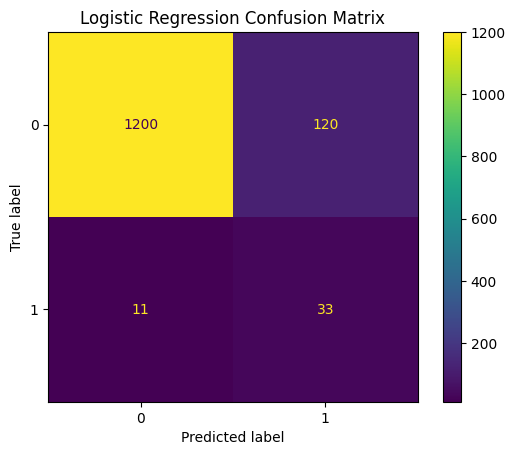

In [ ]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

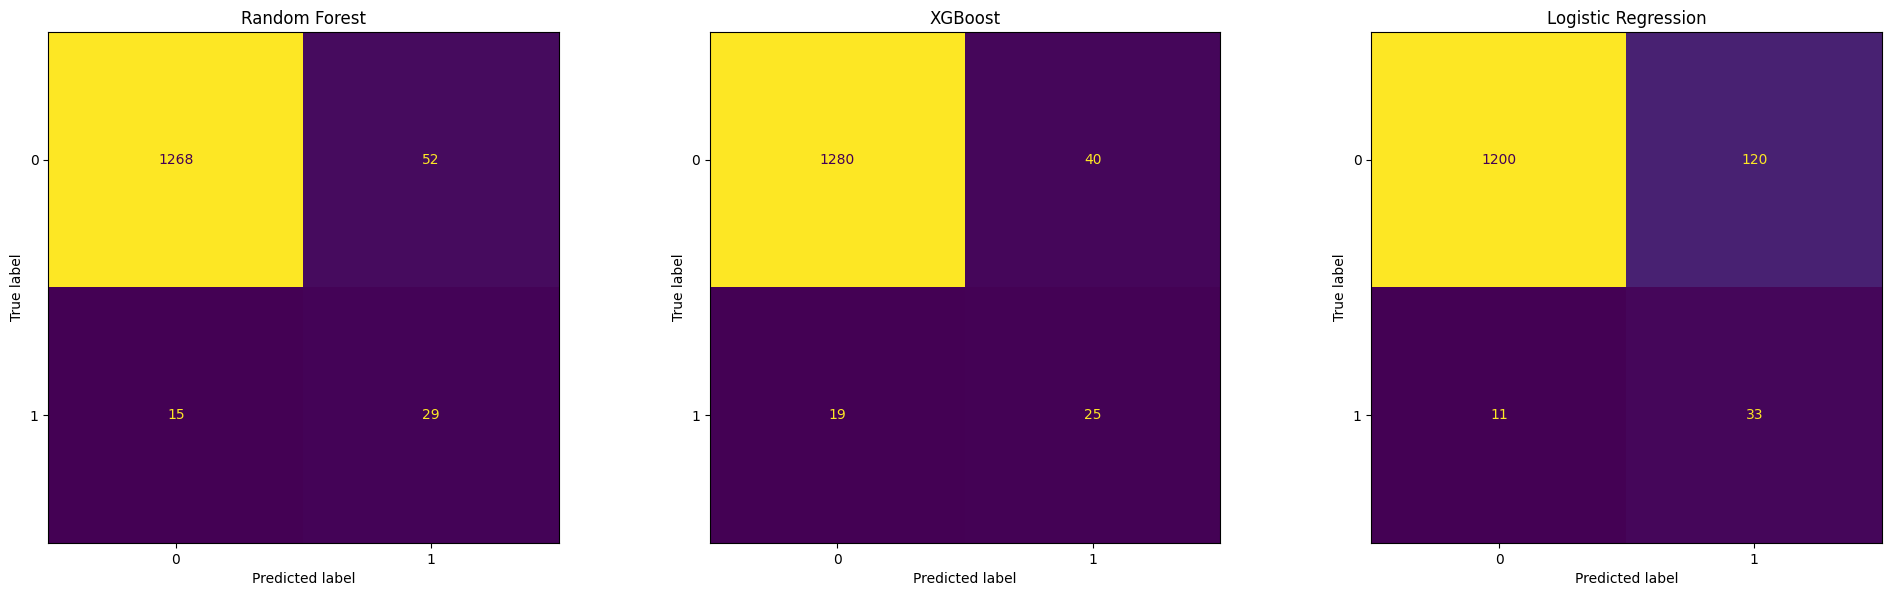

In [ ]:
# Plot all confusion matrices in one figure
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix)
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=xgb_confusion_matrix)
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

# Logistic Regression
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix)
disp_logreg.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

In [ ]:
print("DONEEEEEEE")

DONEEEEEEE



## MODEL PERFORMANCE COMPARISON (6 Preprocessing Combinations)

1. Outliers + No Scale + No SMOTE
------------------------------------------------
Random Forest:
ROC-AUC: 0.7288
Precision: 0.4468
Recall: 0.4773
F1-score: 0.4615
Accuracy: 0.9641

XGBoost:
ROC-AUC: 0.7080
Precision: 0.4750
Recall: 0.4318
F1-score: 0.4524
Accuracy: 0.9663

Logistic Regression:
ROC-AUC: 0.8447
Precision: 0.1748
Recall: 0.8182
F1-score: 0.2880
Accuracy: 0.8695


2. Outliers + Scale + No SMOTE
------------------------------------------------
Random Forest:
ROC-AUC: 0.7273
Precision: 0.4118
Recall: 0.4773
F1-score: 0.4421
Accuracy: 0.9611

XGBoost:
ROC-AUC: 0.7208
Precision: 0.5405
Recall: 0.4545
F1-score: 0.4938
Accuracy: 0.9699

Logistic Regression:
ROC-AUC: 0.8504
Precision: 0.1885
Recall: 0.8182
F1-score: 0.3064
Accuracy: 0.8805


3. Outliers + Scale + SMOTE
------------------------------------------------
Random Forest:
ROC-AUC: 0.8598
Precision: 0.3269
Recall: 0.7727
F1-score: 0.4595
Accuracy: 0.9413

XGBoost:
ROC-AUC: 0.7992
Precision: 0.3590
Recall: 0.6364
F1-score: 0.4590
Accuracy: 0.9516

Logistic Regression:
ROC-AUC: 0.8152
Precision: 0.2000
Recall: 0.7273
F1-score: 0.3137
Accuracy: 0.8974


4. No Outliers + No Scale + No SMOTE
------------------------------------------------
Random Forest:
ROC-AUC: 0.7292
Precision: 0.4565
Recall: 0.4773
F1-score: 0.4667
Accuracy: 0.9648

XGBoost:
ROC-AUC: 0.6875
Precision: 0.5313
Recall: 0.3864
F1-score: 0.4474
Accuracy: 0.9692

Logistic Regression:
ROC-AUC: 0.8795
Precision: 0.1884
Recall: 0.8864
F1-score: 0.3108
Accuracy: 0.8732


5. No Outliers + Scale + No SMOTE
------------------------------------------------
Random Forest:
ROC-AUC: 0.7398
Precision: 0.4490
Recall: 0.5000
F1-score: 0.4731
Accuracy: 0.9641

XGBoost:
ROC-AUC: 0.6977
Precision: 0.5000
Recall: 0.4091
F1-score: 0.4500
Accuracy: 0.9677

Logistic Regression:
ROC-AUC: 0.8530
Precision: 0.1957
Recall: 0.8182
F1-score: 0.3158
Accuracy: 0.8856


6. No Outliers + Scale + SMOTE
------------------------------------------------
Random Forest:
ROC-AUC: 0.8220
Precision: 0.3750
Recall: 0.6818
F1-score: 0.4839
Accuracy: 0.9531

XGBoost:
ROC-AUC: 0.7689
Precision: 0.3846
Recall: 0.5682
F1-score: 0.4587
Accuracy: 0.9567

Logistic Regression:
ROC-AUC: 0.8295
Precision: 0.2157
Recall: 0.7500
F1-score: 0.3350
Accuracy: 0.9040
"""

# FINAL OBSERVATIONS
### EFFECT OF OUTLIERS

- Removing outliers slightly improved model performance.
- Random Forest ROC-AUC increased slightly when outliers were removed.
- Logistic Regression achieved its highest ROC-AUC after removing outliers.
- The improvement is not very large but models became more stable.
- Therefore, removing outliers helps the model generalize better

### EFFECT OF SCALING

- Feature scaling had very little impact on Random Forest and XGBoost.
- This is expected because tree-based models do not depend on feature scale.
- Logistic Regression benefited from scaling because it is a linear model.
- Scaling slightly improved ROC-AUC and model stability for Logistic Regression.
- Overall, scaling is mainly useful for Logistic Regression in this experiment.

### EFFECT OF SMOTE

- SMOTE had the biggest impact on the results.
- The dataset is highly imbalanced with very few bankrupt companies.
- Without SMOTE, models struggled to detect bankrupt companies.
- After applying SMOTE, recall increased significantly for Random Forest and XGBoost.
- This means the models detected more bankrupt companies.
- However, SMOTE slightly increased false positives.
- Overall, SMOTE improved minority class prediction.




- For balanced performance (precision + recall):
  - Best model: Random Forest
  - Best setup: No Outliers + Scaling + SMOTE

- For catching maximum bankrupt companies (highest recall):
  - Best model: Logistic Regression
  - Best setup: No Outliers + No Scaling + No SMOTE

- Overall recommended model: Random Forest


In [ ]:
# Treat outliers
def cap_outliers(df, exclude_cols=['Bankrupt']):
    df_copy = df.copy()
    for col in df_copy.columns:
        if col in exclude_cols:
            continue
        q1 = df_copy[col].quantile(0.25)
        q3 = df_copy[col].quantile(0.75)
        IQR = q3 - q1
        lower_range = q1 - 1.5*IQR
        upper_range = q3 + 1.5*IQR
        df_copy[col] = df_copy[col].clip(lower=lower_range, upper=upper_range)
    return df_copy

# Random Search CV
def get_best_model(model_name, parameters, X_train, Y_train):
    random_search_cv = RandomizedSearchCV(
        estimator=model_name,
        param_distributions=parameters,
        n_jobs=-1,
        n_iter=10,
        cv=5,
        random_state=42
    )
    print("Model started fitting...")
    random_search_cv.fit(X_train, Y_train)
    best_parameters = random_search_cv.best_params_
    best_model = random_search_cv.best_estimator_
    print("Model finished fitting")
    print(f"Best Model: {best_model}")
    print(f"Best Parameters: {best_parameters}")
    return best_parameters, best_model

# Metrics
def metrics(actual, predicted):
    cm = confusion_matrix(actual, predicted)
    roc_auc = roc_auc_score(actual, predicted)
    f1 = f1_score(actual, predicted)
    acc = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)

    print(f"roc_auc_score: {roc_auc}")
    print(f"precision: {precision}")
    print(f"recall: {recall}")
    print(f"f1-score: {f1}")
    print(f"accuracy: {acc}")
    print(f"confusionmatrix:\n{cm}")

    return cm, roc_auc, f1, acc

# Fit model + show metrics
def tuning_model(model, X_train, Y_train, X_test, Y_test):
    print("Model started fitting...")
    model.fit(X_train, Y_train)
    print("Model finished fitting")
    pred = model.predict(X_test)
    return metrics(Y_test, pred)

# train test split
def prepare_data(df, smote=False, scale=False):
    X = df.drop(columns=['Bankrupt'])
    Y = df['Bankrupt']

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, stratify=Y, random_state=42
    )

    if smote:
        sm = SMOTE(random_state=42)
        X_train, Y_train = sm.fit_resample(X_train, Y_train)

    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, Y_train, Y_test

=== RANDOM FOREST ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8106060606060607
precision: 0.3670886075949367
recall: 0.6590909090909091
f1-score: 0.4715447154471545
accuracy: 0.9523460410557185
confusionmatrix:
[[1270   50]
 [  15   29]]


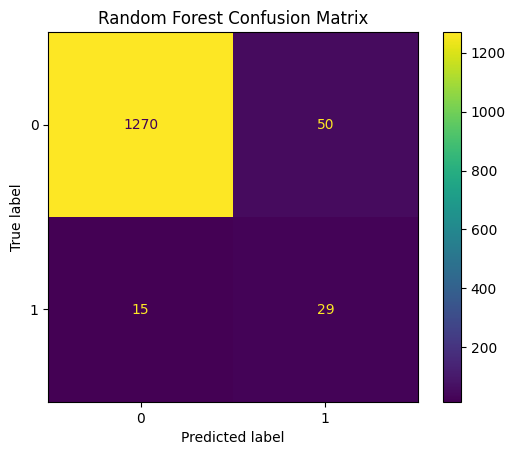

In [ ]:
# FINAL PREPARATION OF MODEL (RANDOM FOREST)
print("=== RANDOM FOREST ===")
data_without_outliers_RF = cap_outliers(data , exclude_cols=['Bankrupt'])
X_train, X_test, Y_train, Y_test = prepare_data(data_without_outliers_RF, smote=True, scale=True)

Final_Random_Forest_Model = RandomForestClassifier(n_estimators = 100,random_state=42 ,class_weight='balanced', criterion='entropy',max_depth=10, min_samples_split=8 , min_samples_leaf= 1)

# Train and evaluate
rf_confusion_matrix_Final, rf_roc_auc, rf_f1_score, rf_accuracy = tuning_model(Final_Random_Forest_Model, X_train, Y_train, X_test, Y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix_Final)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(Final_Random_Forest_Model,"Random_Forest_Model.pkl")
print("Random_Forest_Model_Dumped_Successfully")

Random_Forest_Model_Dumped_Successfully


=== LOGISTIC REGRESSION ===
Model started fitting...
Model finished fitting
roc_auc_score: 0.8791666666666665
precision: 0.1875
recall: 0.8863636363636364
f1-score: 0.30952380952380953
accuracy: 0.8724340175953079
confusionmatrix:
[[1151  169]
 [   5   39]]


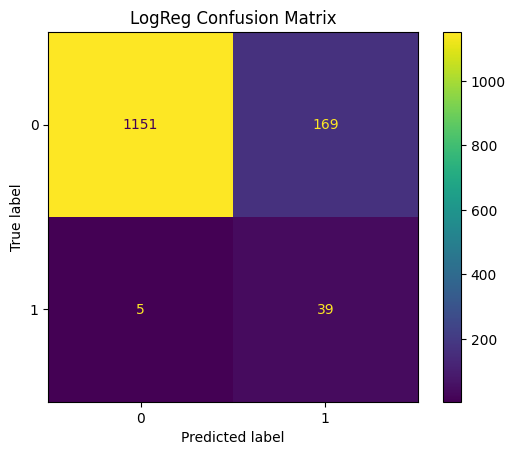

In [ ]:
# FINAL PREPARATION OF MODEL (Logreg FOREST)
print("=== LOGISTIC REGRESSION ===")
data_without_outliers_LOGREG = cap_outliers(data , exclude_cols=['Bankrupt'])
X_train, X_test, Y_train, Y_test = prepare_data(data_without_outliers_LOGREG, smote=False, scale=False)

Final_Logreg_Model = LogisticRegression(C=1, class_weight='balanced',random_state=42, l1_ratio=1,max_iter=1000,penalty='l1', solver='liblinear')

# Train and evaluate
logreg_confusion_matrix_Final, logreg_roc_auc, logreg_f1_score, logreg_accuracy = tuning_model(Final_Logreg_Model, X_train, Y_train, X_test, Y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=logreg_confusion_matrix_Final)
disp.plot()
plt.title("LogReg Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(Final_Logreg_Model,"Logreg_Model.pkl")
print("Final_Logreg_Model_Dumped_Successfully")

Final_Logreg_Model_Dumped_Successfully
